In [ ]:
# ==============================================================================
# STAGE 1: DATA INGESTION & HARMONIZATION
# Cell 1: Environment Setup & Dependencies
# ==============================================================================

import os
import random
import warnings
import gc
import pickle

# Core scientific & data manipulation libraries
import numpy as np
import pandas as pd
import scipy.sparse

# Machine Learning & Gradient Boosting frameworks
import sklearn
import xgboost as xgb
import lightgbm as lgb

# Interpretability & Hyperparameter Optimization
import shap
import optuna

# ------------------------------------------------------------------------------
# Global Configuration & Determinism Settings
# ------------------------------------------------------------------------------
RANDOM_STATE = 42

# Set random seeds across Python, NumPy, and system environment
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)

# Enable Scikit-Learn metadata routing for sample weights propagation in pipelines/ensembles[cite: 3]
sklearn.set_config(enable_metadata_routing=True)

# Configure logging / warnings
warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("Environment setup and dependencies loaded successfully.")
print(f"Global Random Seed: {RANDOM_STATE}")
print(f"Scikit-Learn Metadata Routing: {sklearn.get_config()['enable_metadata_routing']}")

In [ ]:
#no need to play cell 2 and 3 again

In [ ]:
##Cell 2: Metadata Cleaning & MIC Parsing (Consolidates Cells 2, 3, 4) and shortened it


import pandas as pd
import numpy as np
import re
import requests
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
METADATA_CSV = "/kaggle/input/k-pneumoniae-amr/klebsiella_metadata.csv.csv"
FINAL_DOWNLOAD_LIST = "final_download_list.txt"
OUTPUT_FILE = "phenotypes_clean.csv"

# 1. Load and clean metadata ONCE
df = pd.read_csv(METADATA_CSV, dtype=str)
df.columns = df.columns.str.strip()
df_clean = df.dropna(subset=['Measurement Value'])
df_clean = df_clean[df_clean['Measurement Value'].str.strip() != '']
potential_ids = df_clean['Genome ID'].unique()

print(f"Pinging server for {len(potential_ids)} genomes with MIC data...")

# 2. Ping server to verify genome files exist
def check_server(gid):
    try:
        url = f"https://www.bv-brc.org/api/genome_sequence/?eq(genome_id,{gid})&select(genome_id)&limit(1)"
        if requests.get(url, headers={"Accept": "application/json"}, timeout=3).status_code == 200:
            return gid
    except:
        pass
    return None

with ThreadPoolExecutor(max_workers=20) as executor:
    valid_ids = set(gid for gid in tqdm(executor.map(check_server, potential_ids), total=len(potential_ids)) if gid)

# Save the final valid list for later downloading
with open(FINAL_DOWNLOAD_LIST, "w") as f:
    for gid in valid_ids: f.write(f"{gid}\n")

# 3. Filter DataFrame to only include validated IDs
df_final_valid = df_clean[df_clean['Genome ID'].isin(valid_ids)].copy()

# 4. Parse MIC values
def parse_mic(val):
    val = str(val).strip()
    multiplier = 2.0 if '>' in val else 0.5 if '<' in val else 1.0
    try: return float(re.sub(r"[^0-9\.]", "", val)) * multiplier
    except: return np.nan

df_final_valid['MIC_Float'] = df_final_valid['Measurement Value'].apply(parse_mic)
df_final_valid = df_final_valid.dropna(subset=['MIC_Float'])

# 5. Pivot and Save
df_pivot = df_final_valid.pivot_table(index='Genome ID', columns='Antibiotic', values='MIC_Float', aggfunc='median')
top_drugs = df_pivot.count().sort_values(ascending=False).head(5).index.tolist()
df_final = df_pivot[top_drugs]

df_final.to_csv(OUTPUT_FILE)
print(f"Saved {OUTPUT_FILE} with {len(df_final)} rows for drugs: {top_drugs}")

In [ ]:
# ==============================================================================
# Cell 3: Genome File Verification & Alignment
# ==============================================================================

import os
import requests
import gzip
import time
import random
import shutil
import pandas as pd
from concurrent.futures import ThreadPoolExecutor
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
INPUT_LIST = "final_download_list.txt"
OUTPUT_DIR = "genomes_compressed"
ZIP_NAME = "klebsiella_genomes_v1"
PHENOTYPE_FILE = "phenotypes_clean.csv"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Load Valid IDs
with open(INPUT_LIST, "r") as f:
    genome_ids = [line.strip() for line in f if line.strip()]

print(f"🚀 Starting robust download for {len(genome_ids)} genomes...")

# 2. Smart Download Function
def download_worker(gid):
    filepath = os.path.join(OUTPUT_DIR, f"{gid}.fna.gz")
    if os.path.exists(filepath): 
        return "Exists"
    
    url = f"https://www.bv-brc.org/api/genome_sequence/?eq(genome_id,{gid})&limit(25000)"
    headers = {"Accept": "application/dna+fasta", "User-Agent": "Mozilla/5.0"}
    try:
        time.sleep(random.uniform(0.1, 0.4))
        with requests.get(url, headers=headers, stream=True, timeout=45) as r:
            if r.status_code == 200:
                with gzip.open(filepath, 'wb') as f_out:
                    for chunk in r.iter_content(chunk_size=8192):
                        f_out.write(chunk)
                if os.path.getsize(filepath) > 500:
                    return "Success"
                else:
                    os.remove(filepath)
    except Exception:
        pass
    
    if os.path.exists(filepath): 
        os.remove(filepath)
    return "Failed"

# 3. Execute Download with ThreadPool
with ThreadPoolExecutor(max_workers=8) as executor:
    results = list(tqdm(executor.map(download_worker, genome_ids), total=len(genome_ids)))

success_count = results.count("Success") + results.count("Exists")
print(f"\n✅ Downloaded: {success_count} | ❌ Failed: {results.count('Failed')}")

# 4. Align with phenotypes_clean.csv
# We must ensure our matrix only contains isolates we successfully downloaded
downloaded_gids = [gid for gid, res in zip(genome_ids, results) if res in ["Success", "Exists"]]
df_pheno = pd.read_csv(PHENOTYPE_FILE, index_col=0)
df_pheno_aligned = df_pheno[df_pheno.index.astype(str).isin(downloaded_gids)]
df_pheno_aligned.to_csv(PHENOTYPE_FILE)
print(f"✅ Aligned phenotype matrix to {len(df_pheno_aligned)} successfully downloaded genomes.")

# 5. Bundle into Zip Archive
print(f"📦 Bundling {success_count} files into {ZIP_NAME}.zip...")
shutil.make_archive(ZIP_NAME, 'zip', OUTPUT_DIR)
print("🎉 Done! Ready for matrix processing.")

In [ ]:
#Stage 2: K-mer Matrix Construction

#-----------------------------------------------------------                  no need to run again
#Cell 4: Sparse Hashing Vectorization (Consolidates Cell 14)
#-----------------------------------------------------------

import os
import pandas as pd
import numpy as np
import scipy.sparse
import pickle
from sklearn.feature_extraction.text import HashingVectorizer
from tqdm.notebook import tqdm

# --- CONFIGURATION ---
# Update to your unzipped Kaggle dataset directory path
DATA_DIR = "/kaggle/input/datasets/muskan12345678910/klebsiella-amr-genomes-v1" 

# Make sure this points to wherever your phenotypes_clean.csv is located now
PHENOTYPE_FILE = "/kaggle/input/datasets/muskan12345678910/phenotypes-clean/phenotypes_clean.csv" 

# TUNING
BATCH_SIZE = 50
K_MER_SIZE = 11
N_FEATURES = 2**18 

print("🚀 INITIALIZING UNIVERSAL MATRIX FACTORY...")

# 1. LOAD LABELS & PREPARE
df_labels = pd.read_csv(PHENOTYPE_FILE, index_col=0)
target_ids = set(df_labels.index.astype(str))

vectorizer = HashingVectorizer(
    analyzer='char', 
    ngram_range=(K_MER_SIZE, K_MER_SIZE), 
    n_features=N_FEATURES, 
    dtype=np.float32, 
    norm='l2'
)

# 2. SCAN FOLDER DIRECTLY
print(f"📖 Scanning directory: {DATA_DIR}...")
valid_files = []

for root, dirs, files in os.walk(DATA_DIR):
    for f in files:
        if f.endswith('.fna'): # Updated to look for .fna
            gid = f.replace('.fna', '')
            if gid in target_ids:
                valid_files.append((gid, os.path.join(root, f)))

print(f"Found {len(valid_files)} matching genomes. Starting extraction...")

parts, ids = [], []
batch_text, batch_ids = [], []

for idx, (gid, file_path) in enumerate(tqdm(valid_files)):
    try:
        # Updated to read plain text files instead of gzip
        with open(file_path, 'r') as f:
            seq = "".join(line.strip().upper() for line in f if not line.startswith(">"))
            batch_text.append(seq.replace('N', ''))
            batch_ids.append(gid)
    except Exception:
        pass # Skip corrupted files safely
        
    # Process batch
    if len(batch_text) == BATCH_SIZE or idx == len(valid_files) - 1:
        if batch_text:
            X_batch = vectorizer.transform(batch_text)
            parts.append(X_batch)
            ids.extend(batch_ids)
            batch_text, batch_ids = [], [] # Clear memory

# 3. MERGE & SAVE
print("🔗 Merging and saving final matrix...")
if parts:
    X_final = scipy.sparse.vstack(parts).tocsr()
    scipy.sparse.save_npz("X_features.npz", X_final)
    with open("genome_ids.pkl", "wb") as f: 
        pickle.dump(ids, f)
    print(f"🎉 SUCCESS! Matrix Saved: {X_final.shape}")
else:
    print("❌ ERROR: No data processed. Check your file paths and IDs.")

#this took lots of time so i am just using the old matrix. this is the sparse matrix, abhi tak top 5000 choose nhi hua


In [ ]:
# ==============================================================================   no need to run again
# Cell 5: Hybrid Memory-Safe f_regression Filtering (Stage 3)
# ==============================================================================


import os
import gc
import pickle
import numpy as np
import pandas as pd
import scipy.sparse
from sklearn.feature_selection import f_regression
import random

# --- CONFIGURATION ---
INPUT_MATRIX = "/kaggle/input/matrix-and-pkl/X_features.npz"
INPUT_IDS = "/kaggle/input/matrix-and-pkl/genome_ids.pkl"
PHENOTYPE_FILE = "/kaggle/input/datasets/muskan12345678910/phenotypes-clean/phenotypes_clean.csv"
OUTPUT_DIR = "stage3_features"

TOP_K = 5000 
DRUGS = ["meropenem", "ciprofloxacin", "colistin"]
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("🚀 STARTING DRUG-BY-DRUG RAM-WIPING REDUCTION...")

# Load IDs and Labels once
with open(INPUT_IDS, "rb") as f: 
    genome_ids = pickle.load(f)
df_labels = pd.read_csv(PHENOTYPE_FILE, index_col=0)
gid_to_idx = {str(gid): idx for idx, gid in enumerate(genome_ids)}

for drug in DRUGS:
    print(f"\n{'='*40}\n🧬 PROCESSING: {drug.upper()}\n{'='*40}")
    
    # 1. Find valid rows for this drug
    valid_indices, y_mic_vals = [], []
    for gid in df_labels.index:
        if str(gid) in gid_to_idx:
            val = df_labels.loc[gid, drug]
            if isinstance(val, pd.Series): val = val.iloc[0]
            try:
                val = float(val)
                if pd.notna(val) and val > 0:
                    valid_indices.append(gid_to_idx[str(gid)])
                    y_mic_vals.append(np.log2(val))
            except ValueError: continue
            
    y_mic_array = np.array(y_mic_vals, dtype=np.float32)
    np.save(f"{OUTPUT_DIR}/y_mic_{drug}.npy", y_mic_array)
    print(f"✅ Found {len(valid_indices)} valid samples.")

    # 2. Load Base Matrix & Instantly Subset Rows
    print("Loading Base Matrix into RAM...")
    X_base = scipy.sparse.load_npz(INPUT_MATRIX) # Loads natively as CSR (low RAM)
    
    print("Subsetting rows and wiping base matrix from memory...")
    X_valid_csr = X_base[valid_indices, :] 
    del X_base 
    gc.collect() # RAM is immediately freed
    
    # Now safe to convert the smaller subset to CSC
    X_valid_csc = X_valid_csr.tocsc()
    del X_valid_csr
    gc.collect()

    # 3. Scouting (Chunked f_regression)
    subset_size = min(1500, len(valid_indices))
    subset_positions = sorted(random.sample(range(len(valid_indices)), subset_size))
    y_subset = y_mic_array[subset_positions]
    X_subset = X_valid_csc[subset_positions, :]
    
    print("📊 Running chunked f_regression...")
    CHUNK_SIZE = 25000
    all_f_scores = []
    
    for start in range(0, X_subset.shape[1], CHUNK_SIZE):
        end = min(start + CHUNK_SIZE, X_subset.shape[1])
        X_chunk = X_subset[:, start:end].toarray()
        f_scores, _ = f_regression(X_chunk, y_subset)
        all_f_scores.extend(f_scores)
        del X_chunk
        gc.collect()

    # 4. Extract Top Indices
    all_f_scores = np.nan_to_num(np.array(all_f_scores))
    top_feature_indices = np.argsort(all_f_scores)[-TOP_K:]
    top_feature_indices = np.sort(top_feature_indices)
    np.save(f"{OUTPUT_DIR}/top_indices_{drug}.npy", top_feature_indices)
    
    # 5. Build Compact Matrix
    print("💾 Slicing and saving optimized matrix...")
    X_final = X_valid_csc[:, top_feature_indices].tocsr()
    matrix_path = f"{OUTPUT_DIR}/X_{drug}_top{TOP_K}.npz"
    scipy.sparse.save_npz(matrix_path, X_final)
    print(f"🎉 Saved: {matrix_path}")
    
    # 6. TOTAL WIPE BEFORE NEXT DRUG
    del X_valid_csc, X_subset, y_subset, all_f_scores, X_final, top_feature_indices
    gc.collect()

print("\n✅ STAGE 3 COMPLETE.")

In [ ]:
# ==============================================================================  no need to run again
# Cell 6: Epistasis (Interaction) Matrix Engineering (Stage 4)
# ==============================================================================
import os
import gc
import numpy as np
import scipy.sparse
from itertools import combinations
from sklearn.feature_selection import f_regression

# --- CONFIGURATION ---
INPUT_DIR = "/kaggle/input/datasets/muskan12345678910/top-5000-new"
OUTPUT_DIR = "stage4_features"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DRUGS = ["meropenem", "ciprofloxacin", "colistin"]
TOP_N = 50
MIN_OCCURRENCE = 5

print(f"🧬 STARTING EPISTASIS ENGINEERING (Top {TOP_N} Interactions)...")

for drug in DRUGS:
    print(f"\n{'='*40}\n⚙️ PROCESSING: {drug.upper()}\n{'='*40}")
    
    # 1. Load Stage 3 Data
    X_base = scipy.sparse.load_npz(f"{INPUT_DIR}/X_{drug}_top5000.npz")
    y_mic = np.load(f"{INPUT_DIR}/y_mic_{drug}.npy")
    
    # 2. Score the 5,000 features to find the absolute Top 50
    # X_base is small enough (~5000 cols) to safely convert to dense for scoring
    print("📊 Ranking the top 5,000 features...")
    f_scores, _ = f_regression(X_base.toarray(), y_mic)
    f_scores = np.nan_to_num(f_scores)
    
    # Get local indices of the top 50 features
    top_50_local_idx = np.argsort(f_scores)[-TOP_N:]
    
    # 3. Extract the Top 50 as a dense array for fast logical operations
    X_top50 = X_base[:, top_50_local_idx].toarray()
    
    # 4. Generate Pairwise Interactions
    print(f"🔗 Computing all 1,225 pairwise combinations...")
    valid_interactions = []
    
    for i, j in combinations(range(TOP_N), 2):
        # Logical AND: Feature i AND Feature j are both present (> 0)
        combined = (X_top50[:, i] > 0) & (X_top50[:, j] > 0)
        
        # Filter by biological relevance (must co-occur in at least MIN_OCCURRENCE strains)
        if np.sum(combined) >= MIN_OCCURRENCE:
            valid_interactions.append(combined.astype(np.float32))
            
    # 5. Concatenate and Save
    if valid_interactions:
        # Convert interactions list to a sparse CSR matrix
        X_int = scipy.sparse.csr_matrix(np.column_stack(valid_interactions))
        
        # Horizontally stack: Base 5000 + New Interactions
        X_enhanced = scipy.sparse.hstack([X_base, X_int]).tocsr()
        
        save_path = f"{OUTPUT_DIR}/X_{drug}_epistasis.npz"
        scipy.sparse.save_npz(save_path, X_enhanced)
        
        print(f"🎉 Success! Generated {len(valid_interactions)} valid interactions.")
        print(f"💾 Enhanced Matrix Saved: {save_path} (Shape: {X_enhanced.shape})")
        
        del X_int, X_enhanced
    else:
        print("⚠️ No valid interactions met the minimum occurrence threshold.")
        scipy.sparse.save_npz(f"{OUTPUT_DIR}/X_{drug}_epistasis.npz", X_base)
        
    # Total Wipe for RAM safety
    del X_base, y_mic, f_scores, X_top50, valid_interactions
    gc.collect()

print("\n✅ STAGE 4 COMPLETE. Epistasis matrices are ready for ML modeling.")


In [ ]:
# ===============================================================================  no need to run again
# Cell 6.5: Population Structure (Lineage) Approximation
# ==============================================================================
import os
import numpy as np
import scipy.sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans

# --- CONFIGURATION ---
# Point this to your actual Kaggle input path where the epistasis matrices live
INPUT_DIR = "/kaggle/input/datasets/muskan12345678910/new-epistasis"
# Save outputs to the writable working directory
OUTPUT_DIR = "./" 

DRUGS = ["meropenem", "ciprofloxacin", "colistin"]
N_COMPONENTS = 50   # Number of dimensions to represent genomic background
N_CLUSTERS = 100     # Approximate number of distinct clonal lineages

print("🧬 STARTING PHYLOGENETIC BACKGROUND APPROXIMATION...")

for drug in DRUGS:
    print(f"\n{'='*40}\n🦠 MAPPING LINEAGES: {drug.upper()}\n{'='*40}")
    
    try:
        matrix_path = f"{INPUT_DIR}/X_{drug}_epistasis.npz"
        if not os.path.exists(matrix_path):
            print(f"⚠️ Skipping {drug}: Epistasis matrix not found.")
            continue
            
        X_enhanced = scipy.sparse.load_npz(matrix_path)
        print(f"Loaded matrix: {X_enhanced.shape}")
        
        print("📉 Compressing genomic signatures (TruncatedSVD)...")
        svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
        X_pca = svd.fit_transform(X_enhanced)
        
        explained_variance = np.sum(svd.explained_variance_ratio_) * 100
        print(f"Captured {explained_variance:.2f}% of genomic variance.")
        
        print(f"🧫 Grouping genomes into {N_CLUSTERS} distinct lineages...")
        kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
        lineage_groups = kmeans.fit_predict(X_pca)
        
        # FIX: Save to the writable OUTPUT_DIR
        save_path = f"{OUTPUT_DIR}lineage_groups_{drug}.npy"
        np.save(save_path, lineage_groups)
        print(f"🎉 Lineage map saved: {save_path}")
        
    except Exception as e:
        print(f"❌ Error processing {drug}: {e}")

print("\n✅ POPULATION STRUCTURE MAPPED. Ready for Group-Aware Cross Validation.")

In [ ]:
#  NEW stage 3 that makes lineage aware top 5000 features

In [ ]:
# ==============================================================================
# UNIFIED STAGE 3: Ultra-Low RAM Lineage-Aware Feature Selection + Index Exporter
# ==============================================================================
import os
import gc
import numpy as np
import scipy.sparse
import pandas as pd
from sklearn.feature_selection import f_regression
from sklearn.model_selection import GroupKFold

# --- CONFIGURATION ---
INPUT_MATRIX = "/kaggle/input/matrix-and-pkl/X_features.npz"
INPUT_IDS = "/kaggle/input/matrix-and-pkl/genome_ids.pkl"
PHENOTYPE_FILE = "/kaggle/input/datasets/muskan12345678910/phenotypes-clean/phenotypes_clean.csv"
LINEAGE_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-map"

OUTPUT_DIR = "Lineage-aware-top-5000"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DRUGS = ["meropenem", "colistin", "ciprofloxacin"]
TOP_N = 5000
GENOME_ID_COL = "Genome ID"
CHUNK_SIZE = 5000  # 5,000 features at a time to protect RAM

print("🚀 STARTING UNIFIED LINEAGE-AWARE FEATURE SELECTION...")

# 1. Load Master Data
print("Loading master feature matrix...")
X_master = scipy.sparse.load_npz(INPUT_MATRIX).tocsr()
genome_ids_master = pd.read_pickle(INPUT_IDS)
phenotypes = pd.read_csv(PHENOTYPE_FILE)
phenotypes[GENOME_ID_COL] = phenotypes[GENOME_ID_COL].astype(str)

df_master = pd.DataFrame({
    GENOME_ID_COL: [str(i) for i in genome_ids_master],
    'matrix_idx': np.arange(len(genome_ids_master))
})

for drug in DRUGS:
    print(f"\n{'='*50}\n🧬 PROCESSING: {drug.upper()}\n{'='*50}")
    
    try:
        # 2. Strict Alignment
        drug_pheno = phenotypes[[GENOME_ID_COL, drug]].dropna()
        merged = pd.merge(df_master, drug_pheno, on=GENOME_ID_COL, how='inner')
        lineages = np.load(f"{LINEAGE_DIR}/lineage_groups_{drug}.npy")
        
        # Surgical slice if rows exceed lineage map (e.g., Ciprofloxacin)
        if len(merged) > len(lineages):
            print(f"Trimming {len(merged) - len(lineages)} row(s) to match Lineage Map ({len(lineages)})...")
            merged = merged.iloc[:len(lineages)]
            
        X_drug_raw = X_master[merged['matrix_idx'].values].tocsr()
        y_mic = np.log2(merged[drug].values)
        
        print(f"✅ Aligned Matrix shape: {X_drug_raw.shape[0]} rows (Target: {len(lineages)} lineages)")
        
        if X_drug_raw.shape[0] != len(lineages):
            print(f"❌ Alignment failed! Matrix rows do not match Lineage map.")
            continue
            
        # 3. Lineage-Aware Scoring with Micro-Chunking
        gkf = GroupKFold(n_splits=5)
        aggregated_f_scores = np.zeros(X_drug_raw.shape[1])
        
        print("Running fold-by-fold F-Regression...")
        for fold, (train_idx, _) in enumerate(gkf.split(X_drug_raw, y_mic, groups=lineages)):
            X_train = X_drug_raw[train_idx]
            y_train = y_mic[train_idx]
            
            fold_scores = np.zeros(X_drug_raw.shape[1])
            
            for start in range(0, X_train.shape[1], CHUNK_SIZE):
                end = min(start + CHUNK_SIZE, X_train.shape[1])
                X_chunk = X_train[:, start:end].toarray()
                
                scores, _ = f_regression(X_chunk, y_train)
                fold_scores[start:end] = np.nan_to_num(scores)
                
                del X_chunk, scores
                
            aggregated_f_scores += fold_scores
            print(f"   ✓ Fold {fold + 1} scored.")
            
            del X_train, y_train, fold_scores
            gc.collect()
            
        # 4. Extract Universal Top 5,000 & SAVE THE INDICES
        print(f"Extracting Top {TOP_N} universal features...")
        top_5000_idx = np.argsort(aggregated_f_scores)[-TOP_N:]
        X_drug_top5000 = X_drug_raw[:, top_5000_idx]
        
        # Save matrices and targets
        scipy.sparse.save_npz(f"{OUTPUT_DIR}/X_{drug}_top5000_lineage_aware.npz", X_drug_top5000)
        np.save(f"{OUTPUT_DIR}/y_mic_{drug}.npy", y_mic)
        
        # ---> CRITICAL ADDITION: Save the mapping index <---
        np.save(f"{OUTPUT_DIR}/top_5000_idx_{drug}.npy", top_5000_idx)
        
        print(f"✅ Saved matrix, y_mic, and top_5000_idx for {drug.upper()} to {OUTPUT_DIR}")
        
        del X_drug_raw, X_drug_top5000
        gc.collect()
        
    except Exception as e:
        print(f"❌ Error processing {drug}: {e}")

print("\n🏁 STAGE 3 COMPLETE. Mapping indices successfully preserved.")

In [ ]:
# ==============================================================================           no need to run again
# NEW STAGE 4: Lineage-Aware Epistasis (Feature Engineering)
# ==============================================================================
import numpy as np
import scipy.sparse
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import PolynomialFeatures
import os

INPUT_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-aware-top-5000"
OUTPUT_DIR = "./Lineage-aware-epistasis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DRUGS = ["meropenem", "ciprofloxacin", "colistin"]

print("🚀 GENERATING PURE EPISTATIC INTERACTIONS...")

for drug in DRUGS:
    print(f"\n🧬 Processing {drug.upper()}...")
    try:
        # Load the pure top 5000 features
        X_top5000 = scipy.sparse.load_npz(f"{INPUT_DIR}/X_{drug}_top5000_lineage_aware.npz")
        
        # 1. Compress 5,000 features into 50 core genetic pathways (SVD is sparse-safe)
        svd = TruncatedSVD(n_components=50, random_state=42)
        X_pca = svd.fit_transform(X_top5000)
        
        # 2. Generate pairwise interactions between those 50 pathways
        poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
        X_interactions = poly.fit_transform(X_pca)
        
        # 3. Combine original pure features with their interactions
        X_interactions_sparse = scipy.sparse.csr_matrix(X_interactions)
        X_enhanced = scipy.sparse.hstack([X_top5000, X_interactions_sparse])
        
        # Save the enhanced matrix (5,000 base + 1,225 interactions = 6,225 features)
        scipy.sparse.save_npz(f"{OUTPUT_DIR}/X_{drug}_epistasis.npz", X_enhanced)
        
        print(f"   ✓ Enhanced shape: {X_enhanced.shape}")
        
    except Exception as e:
        print(f"❌ Error on {drug}: {e}")

In [1]:
# ==============================================================================
# Cells 7 & 8: Sample Weighting & Model Definitions (Stage 5)
# ==============================================================================
import numpy as np
from collections import Counter
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
import sklearn

# Enable metadata routing globally
sklearn.set_config(enable_metadata_routing=True)

print("⚖️ CONFIGURING BALANCED WEIGHTS & MODEL FACTORY...")

def get_sample_weights(y_train, power=0.5):
    y_rounded = np.round(y_train * 2) / 2
    counts = Counter(y_rounded)
    total = len(y_train)
    weights = np.array([(total / (counts[val] + 1))**power for val in y_rounded])
    weight_cap = np.percentile(weights, 90)
    weights = np.clip(weights, a_min=None, a_max=weight_cap)
    return weights / np.mean(weights)

# --- THE FIX: Add .set_fit_request(sample_weight=True) to base learners ---
xgb_base = xgb.XGBRegressor(
    n_estimators=300, 
    max_depth=6, 
    learning_rate=0.03,
    tree_method='hist',
    objective='reg:pseudohubererror', 
    reg_alpha=1.0, 
    reg_lambda=10.0,
    random_state=42,
    n_jobs=2,
    verbosity=0
).set_fit_request(sample_weight=True)

lgb_base = lgb.LGBMRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.03,
    objective='huber', 
    reg_alpha=1.0,
    reg_lambda=10.0,
    random_state=42,
    verbose=-1,
    n_jobs=2
).set_fit_request(sample_weight=True)

meta_meropenem = Ridge(alpha=10.0) 
meta_ciprofloxacin = SVR(C=2.0, epsilon=0.1)
meta_colistin = Ridge(alpha=10.0)

def build_stacking_ensemble(drug_name):
    if drug_name == "ciprofloxacin":
        meta_learner = meta_ciprofloxacin
    elif drug_name == "colistin":
        meta_learner = meta_colistin
    else:
        meta_learner = meta_meropenem
        
    return StackingRegressor(
        estimators=[('xgb', xgb_base), ('lgb', lgb_base)],
        final_estimator=meta_learner,
        cv=5, 
        n_jobs=2
    )

print("✅ STAGE 5 COMPLETE.")

⚖️ CONFIGURING BALANCED WEIGHTS & MODEL FACTORY...
✅ STAGE 5 COMPLETE.


In [4]:
# ==============================================================================
# COLISTIN-ONLY PIPELINE: Stacking Regressor + Physical 1:1 Downsampling
# ==============================================================================
import os
import warnings
import numpy as np
import scipy.sparse

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    mean_squared_error, r2_score, roc_auc_score, recall_score, 
    precision_score, average_precision_score, roc_curve
)
import sklearn

warnings.filterwarnings('ignore')
sklearn.set_config(enable_metadata_routing=False) 

# --- 1. BALANCING ENGINE ---
def balance_training_data(X_train, y_train, limit, ratio=1.0):
    res_idx = np.where(y_train > limit)[0]
    sus_idx = np.where(y_train <= limit)[0]
    n_res = len(res_idx)
    n_sus_target = int(n_res * ratio)
    
    if len(sus_idx) > n_res:
        np.random.seed(42)
        sus_idx_sampled = np.random.choice(sus_idx, size=n_sus_target, replace=False)
    else:
        sus_idx_sampled = sus_idx
        
    balanced_idx = np.concatenate([res_idx, sus_idx_sampled])
    np.random.shuffle(balanced_idx)
    return X_train[balanced_idx], y_train[balanced_idx]

# --- 2. FAST BASE LEARNERS & MODEL ---
xgb_base = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03, tree_method='hist', device='cuda', objective='reg:pseudohubererror', reg_alpha=1.0, reg_lambda=10.0, random_state=42, verbosity=0)
lgb_base = lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.03, objective='huber', reg_alpha=1.0, reg_lambda=10.0, random_state=42, verbose=-1, n_jobs=2)
cat_base = CatBoostRegressor(iterations=500, depth=4, learning_rate=0.05, loss_function='RMSE', l2_leaf_reg=10.0, random_seed=42, verbose=0, task_type='GPU')

def build_colistin_model():
    # Full Trinity Stack for Colistin
    return StackingRegressor(
        estimators=[('xgb', xgb_base), ('lgb', lgb_base), ('cat', cat_base)], 
        final_estimator=Ridge(alpha=10.0), 
        cv=5, 
        n_jobs=1
    )

# --- 3. EVALUATION EXECUTION ---
INPUT_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-aware-epistasis"
Y_MIC_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-aware-top-5000-better"
LINEAGE_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-map"
OUTPUT_DIR = "./Final_Results_Optimized"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DRUG = "colistin"
BREAKPOINT = 2.0

print(f"🚀 STARTING {DRUG.upper()} DOWNSAMPLING PIPELINE...")
print(f"\n{'='*60}\n🔬 EVALUATING: {DRUG.upper()}\n{'='*60}")

try:
    X_enhanced = scipy.sparse.load_npz(f"{INPUT_DIR}/X_{DRUG}_epistasis.npz")
    y_mic = np.load(f"{Y_MIC_DIR}/y_mic_{DRUG}.npy")
    lineage_groups = np.load(f"{LINEAGE_DIR}/lineage_groups_{DRUG}.npy")
    limit = np.log2(BREAKPOINT)
    y_class_true = (y_mic > limit).astype(int)
    
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_cv = np.zeros_like(y_mic)
    model = build_colistin_model()
    
    for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_enhanced, y_class_true, groups=lineage_groups)):
        X_train, y_train = X_enhanced[train_idx], y_mic[train_idx]
        X_test = X_enhanced[test_idx]
        
        # Apply 1:1 Downsampling directly
        X_train_bal, y_train_bal = balance_training_data(X_train, y_train, limit)
        model.fit(X_train_bal, y_train_bal)
            
        y_pred_cv[test_idx] = model.predict(X_test)
        print(f"   ✓ Fold {fold + 1} complete.")
        
    # --- METRICS CALCULATION ---
    y_pred_snapped = np.round(y_pred_cv * 2) / 2
    ea = np.mean(np.abs(y_mic - y_pred_snapped) <= 1.0) * 100
    
    fpr, tpr, thresholds = roc_curve(y_class_true, y_pred_cv)
    opt_thresh = thresholds[np.argmax(tpr - fpr)]
    y_class_opt = (y_pred_cv >= opt_thresh).astype(int)
    
    total_res = np.sum(y_class_true == 1)
    total_sus = np.sum(y_class_true == 0)
    opt_vme = (np.sum((y_class_true == 1) & (y_class_opt == 0)) / total_res) * 100 if total_res > 0 else 0
    opt_me = (np.sum((y_class_true == 0) & (y_class_opt == 1)) / total_sus) * 100 if total_sus > 0 else 0
    
    roc_auc = roc_auc_score(y_class_true, y_pred_cv)
    pr_auc = average_precision_score(y_class_true, y_pred_cv)
    precision = precision_score(y_class_true, y_class_opt, zero_division=0)

    print(f"\n📊 FINAL METRICS FOR {DRUG.upper()}:")
    print(f"   ➤ Strategy: Downsampling (1:1)")
    print(f"   ➤ Essential Agreement (EA): {ea:.2f}%")
    print(f"   ➤ ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f} | Precision: {precision:.4f}")
    print(f"   ➤ Calibrated Threshold: {opt_thresh:.3f} | Calibrated VME: {opt_vme:.2f}% | Calibrated ME: {opt_me:.2f}%")
    
    np.save(f"{OUTPUT_DIR}/y_pred_cv_{DRUG}_final.npy", y_pred_cv)
    np.save(f"{OUTPUT_DIR}/y_true_{DRUG}.npy", y_mic)
    np.save(f"{OUTPUT_DIR}/y_class_pred_{DRUG}.npy", y_class_opt)

except Exception as e:
    print(f"❌ Error evaluating {DRUG}: {e}")

print("\n🏁 PIPELINE COMPLETE. Artifacts saved for feature extraction.")

🚀 STARTING COLISTIN DOWNSAMPLING PIPELINE...

🔬 EVALUATING: COLISTIN
   ✓ Fold 1 complete.
   ✓ Fold 2 complete.
   ✓ Fold 3 complete.
   ✓ Fold 4 complete.
   ✓ Fold 5 complete.

📊 FINAL METRICS FOR COLISTIN:
   ➤ Strategy: Downsampling (1:1)
   ➤ Essential Agreement (EA): 59.21%
   ➤ ROC-AUC: 0.7838 | PR-AUC: 0.3923 | Precision: 0.3501
   ➤ Calibrated Threshold: 1.277 | Calibrated VME: 23.68% | Calibrated ME: 26.56%

🏁 PIPELINE COMPLETE. Artifacts saved for feature extraction.


In [5]:
# ==============================================================================        # good for mero and ciro, keep this code 
# CONTROLLED EXPERIMENT: Class-Weighting vs. Breakpoint-Weighting
# ==============================================================================
import os
import warnings
import numpy as np
import scipy.sparse
from collections import Counter

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    mean_squared_error, r2_score, roc_auc_score, recall_score, 
    precision_score, average_precision_score
)
import sklearn

warnings.filterwarnings('ignore')
sklearn.set_config(enable_metadata_routing=False) 

# --- 1. THE NEW WEIGHTING ENGINES ---
def get_class_weights(y_train, limit):
    """Weights based strictly on Resistant vs Susceptible imbalance"""
    is_res = y_train > limit
    n_total = len(y_train)
    n_res = np.sum(is_res)
    n_sus = n_total - n_res
    
    # Balance the two classes equally
    w_res = n_total / (2 * n_res) if n_res > 0 else 1.0
    w_sus = n_total / (2 * n_sus) if n_sus > 0 else 1.0
    
    weights = np.where(is_res, w_res, w_sus)
    return weights / np.mean(weights)

def get_breakpoint_weights(y_train, limit):
    """Assigns massive importance to genomes right at the clinical boundary"""
    distance_to_breakpoint = np.abs(y_train - limit)
    
    # Base weight of 1.0
    weights = np.ones_like(y_train)
    
    # If the genome is exactly at or 1 step away from the breakpoint, multiply weight by 5
    near_boundary = distance_to_breakpoint <= 1.0
    weights[near_boundary] *= 5.0
    
    # If it is 2 steps away, multiply by 2
    mid_boundary = (distance_to_breakpoint > 1.0) & (distance_to_breakpoint <= 2.0)
    weights[mid_boundary] *= 2.0
    
    return weights / np.mean(weights)

# --- 2. BASE LEARNERS ---
xgb_base = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.03, tree_method='hist', device='cuda', objective='reg:pseudohubererror', random_state=42, verbosity=0)
lgb_base = lgb.LGBMRegressor(n_estimators=300, max_depth=6, learning_rate=0.03, objective='huber', random_state=42, verbose=-1, n_jobs=2)
cat_base = CatBoostRegressor(iterations=500, depth=4, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=0, task_type='GPU')

def build_model(drug_name):
    if drug_name == "ciprofloxacin":
        return StackingRegressor(estimators=[('xgb', xgb_base), ('lgb', lgb_base)], final_estimator=Ridge(alpha=10.0), cv=5, n_jobs=1)
    return StackingRegressor(estimators=[('xgb', xgb_base), ('lgb', lgb_base), ('cat', cat_base)], final_estimator=Ridge(alpha=10.0), cv=5, n_jobs=1)

# --- 3. EXPERIMENT LOOP ---
INPUT_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-aware-epistasis"
Y_MIC_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-aware-top-5000-better"
LINEAGE_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-map"

DRUGS = ["meropenem", "ciprofloxacin", "colistin"] 
BREAKPOINTS = {"meropenem": 8.0, "ciprofloxacin": 0.5, "colistin": 2.0}

# Testing only Class-Based and Breakpoint-Aware
CONFIGURATIONS = ["Class-Based", "Breakpoint-Aware"]

print("🚀 STARTING CONTROLLED WEIGHTING EXPERIMENT...")

for drug in DRUGS:
    print(f"\n{'='*60}\n🔬 EVALUATING: {drug.upper()}\n{'='*60}")
    
    X_enhanced = scipy.sparse.load_npz(f"{INPUT_DIR}/X_{drug}_epistasis.npz")
    y_mic = np.load(f"{Y_MIC_DIR}/y_mic_{drug}.npy")
    lineage_groups = np.load(f"{LINEAGE_DIR}/lineage_groups_{drug}.npy")
    limit = np.log2(BREAKPOINTS[drug])
    y_class_true = (y_mic > limit).astype(int)
    
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
    
    for config in CONFIGURATIONS:
        print(f"\n   ⚙️ Testing: {config}")
        y_pred_cv = np.zeros_like(y_mic)
        model = build_model(drug)
        
        for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_enhanced, y_class_true, groups=lineage_groups)):
            X_train, y_train = X_enhanced[train_idx], y_mic[train_idx]
            X_test = X_enhanced[test_idx]
            
            if config == "Class-Based":
                weights = get_class_weights(y_train, limit)
                model.fit(X_train, y_train, sample_weight=weights)
            elif config == "Breakpoint-Aware":
                weights = get_breakpoint_weights(y_train, limit)
                model.fit(X_train, y_train, sample_weight=weights)
                
            y_pred_cv[test_idx] = model.predict(X_test)
            
        # --- METRICS AT STRICT BIOLOGICAL BREAKPOINT ---
        y_pred_snapped = np.round(y_pred_cv * 2) / 2
        ea = np.mean(np.abs(y_mic - y_pred_snapped) <= 1.0) * 100
        
        # Use TRUE biological breakpoint limit, NOT Youden's J calibrated threshold
        y_class_pred = (y_pred_cv > limit).astype(int) 
        
        total_res, total_sus = np.sum(y_class_true == 1), np.sum(y_class_true == 0)
        vme = (np.sum((y_class_true == 1) & (y_class_pred == 0)) / total_res) * 100 if total_res > 0 else 0
        me = (np.sum((y_class_true == 0) & (y_class_pred == 1)) / total_sus) * 100 if total_sus > 0 else 0
        
        roc_auc = roc_auc_score(y_class_true, y_pred_cv)
        pr_auc = average_precision_score(y_class_true, y_pred_cv)
        precision = precision_score(y_class_true, y_class_pred, zero_division=0)
        sensitivity = recall_score(y_class_true, y_class_pred, zero_division=0)

        print(f"      EA: {ea:.2f}% | Precision: {precision:.4f} | Sensitivity: {sensitivity:.4f}")
        print(f"      ROC-AUC: {roc_auc:.4f} | PR-AUC: {pr_auc:.4f}")
        print(f"      VME: {vme:.2f}% | ME: {me:.2f}%")

print("\n🏁 EXPERIMENT COMPLETE. Analyze the EA vs Precision trade-offs.")

🚀 STARTING CONTROLLED WEIGHTING EXPERIMENT...

🔬 EVALUATING: MEROPENEM

   ⚙️ Testing: Class-Based


KeyboardInterrupt: 

In [ ]:
# ==============================================================================
# STAGE 7 & 8: Native SHAP & VME Subtraction (Top 20 Drivers)
# ==============================================================================
#Applies the Winning Strategies (Breakpoint for Cipro, Class-Based for Mero, 1:1 for Colistin).
#Calculates exact Native SHAP.
#Calculates the VME Exclusivity Score.
#Filters out housekeeping genes (ensuring target frequency > susceptible frequency) and outputs the Top 20 drivers sorted by SHAP.


import os
import numpy as np
import pandas as pd
import scipy.sparse
import xgboost as xgb

INPUT_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-aware-top-5000-better"
OUTPUT_DIR = "./Final_Resistance_Genes"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DRUGS = ["ciprofloxacin", "meropenem", "colistin"] 
BREAKPOINTS = {"meropenem": 8.0, "ciprofloxacin": 0.5, "colistin": 2.0}

# --- STRATEGY ENGINES ---
def balance_training_data(X_train, y_train, limit, ratio=1.0):
    res_idx = np.where(y_train > limit)[0]
    sus_idx = np.where(y_train <= limit)[0]
    if len(sus_idx) > len(res_idx):
        np.random.seed(42)
        sus_idx = np.random.choice(sus_idx, size=int(len(res_idx)*ratio), replace=False)
    balanced_idx = np.concatenate([res_idx, sus_idx])
    np.random.shuffle(balanced_idx)
    return X_train[balanced_idx], y_train[balanced_idx]

def get_class_weights(y_train, limit):
    is_res = y_train > limit
    n_total = len(y_train)
    n_res, n_sus = np.sum(is_res), n_total - np.sum(is_res)
    w_res = n_total / (2 * n_res) if n_res > 0 else 1.0
    w_sus = n_total / (2 * n_sus) if n_sus > 0 else 1.0
    weights = np.where(is_res, w_res, w_sus)
    return weights / np.mean(weights)

def get_breakpoint_weights(y_train, limit):
    dist = np.abs(y_train - limit)
    weights = np.ones_like(y_train)
    weights[dist <= 1.0] *= 5.0
    weights[(dist > 1.0) & (dist <= 2.0)] *= 2.0
    return weights / np.mean(weights)

print("🧬 STARTING STAGE 7 & 8: SHAP & VME SUBTRACTION...")

for drug in DRUGS:
    print(f"\n{'='*50}\n🔍 ANALYZING: {drug.upper()}\n{'='*50}")
    try:
        X_pure = scipy.sparse.load_npz(f"{INPUT_DIR}/X_{drug}_top5000_lineage_aware.npz")
        y_true = np.load(f"{INPUT_DIR}/y_mic_{drug}.npy")
        top_5000_map = np.load(f"{INPUT_DIR}/top_5000_idx_{drug}.npy")
        limit = np.log2(BREAKPOINTS[drug])
        
        model = xgb.XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.03, 
            tree_method='hist', device='cpu', random_state=42
        )
        
        # Apply Winning Strategies
        if drug == "ciprofloxacin":
            print("   ➤ Applying Breakpoint-Aware Weighting...")
            weights = get_breakpoint_weights(y_true, limit)
            model.fit(X_pure, y_true, sample_weight=weights)
        elif drug == "meropenem":
            print("   ➤ Applying Class-Based Weighting...")
            weights = get_class_weights(y_true, limit)
            model.fit(X_pure, y_true, sample_weight=weights)
        elif drug == "colistin":
            print("   ➤ Applying 1:1 Downsampling...")
            X_bal, y_bal = balance_training_data(X_pure, y_true, limit)
            model.fit(X_bal, y_bal)
            
        y_pred = model.predict(X_pure)
        
        # STAGE 7: SHAP
        print("   ➤ Computing Native SHAP Values...")
        dtrain = xgb.DMatrix(X_pure)
        shap_contribs = model.get_booster().predict(dtrain, pred_contribs=True)
        global_shap = np.abs(shap_contribs[:, :-1]).mean(axis=0)
        
        # STAGE 8: VME Subtraction
        print("   ➤ Isolating VME Cohorts...")
        vme_idx = np.where((y_true >= limit) & (y_pred <= limit))[0]
        sus_idx = np.where(y_true < limit)[0]
        
        if len(vme_idx) > 0:
            freq_target = np.asarray(X_pure[vme_idx].mean(axis=0)).flatten()
        else:
            print("   ⚠️ No VMEs found. Falling back to General Resistance Subtraction.")
            res_idx = np.where(y_true >= limit)[0]
            freq_target = np.asarray(X_pure[res_idx].mean(axis=0)).flatten()
            
        freq_sus = np.asarray(X_pure[sus_idx].mean(axis=0)).flatten()
        
        # Formula: Score = Freq_Target - (Freq_Susceptible * 2.0)
        exclusivity_scores = freq_target - (freq_sus * 2.0)
        
        feature_df = pd.DataFrame({
            'Local_Index': np.arange(len(global_shap)),
            'Global_Hash_Index': top_5000_map,
            'SHAP_Importance': global_shap,
            'VME_Exclusivity_Score': exclusivity_scores
        })
        
        # Filter housekeeping genes (must be more enriched in target than susceptible background)
        valid_mask = freq_target > freq_sus
        top_20 = feature_df[valid_mask].sort_values(
            by=['SHAP_Importance', 'VME_Exclusivity_Score'], ascending=[False, False]
        ).head(20)
        
        print(f"   ✓ Top 5 targets by SHAP & Exclusivity:")
        print(top_20.head(5).to_string(index=False))
        
        csv_path = f"{OUTPUT_DIR}/top_20_shap_targets_{drug}.csv"
        top_20.to_csv(csv_path, index=False)
        print(f"   💾 Saved Top 20 list to: {csv_path}")
        
    except Exception as e:
        print(f"❌ Error: {e}")

print("\n✅ SHAP AND VME SUBTRACTION COMPLETE.")

In [ ]:
# ==============================================================================
# DICTIONARY ATTACK: Recovering Top 20 SHAP DNA Strings
# ==============================================================================
import itertools
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import HashingVectorizer
import os

INPUT_DIR = "/kaggle/input/datasets/muskan12345678910/final-resistance-genes-20"
WORKING_DIR = "/kaggle/working/Final_Resistance_Genes_Translated"
os.makedirs(WORKING_DIR, exist_ok=True)

DRUGS = ["ciprofloxacin", "meropenem", "colistin"]

# 1. Initialize Vectorizer
vectorizer = HashingVectorizer(
    analyzer='char', ngram_range=(11, 11), 
    n_features=2**18, dtype=np.float32, norm='l2'
)

# 2. Generate and Hash Library
print("🧬 Generating 4.19M theoretical DNA combinations...")
nucleotides = ['A', 'T', 'C', 'G']
all_11mers = [''.join(p) for p in itertools.product(nucleotides, repeat=11)]
X_all = vectorizer.transform(all_11mers)
rows, cols = X_all.nonzero()

for drug in DRUGS:
    print(f"\n🔍 Recovering strings for {drug.upper()}...")
    try:
        df = pd.read_csv(f"{INPUT_DIR}/top_20_shap_targets_{drug}.csv")
        target_hashes = set(df['Global_Hash_Index'].tolist())
        
        hash_to_kmers = {h: [] for h in target_hashes}
        
        for row_idx, hash_idx in zip(rows, cols):
            if hash_idx in target_hashes:
                hash_to_kmers[hash_idx].append(all_11mers[row_idx])
                
        df['Recovered_11_mers'] = df['Global_Hash_Index'].apply(
            lambda h: "|".join(hash_to_kmers[h]) if h in hash_to_kmers else "NOT_FOUND"
        )
        
        csv_path = f"{WORKING_DIR}/top_20_translated_{drug}.csv"
        df.to_csv(csv_path, index=False)
        print(f"   ✅ Saved translated sequences to {csv_path}")
        
    except Exception as e:
        print(f"❌ Error processing {drug}: {e}")

🎨 STARTING SHAP VISUALIZATION...

📊 PLOTTING: CIPROFLOXACIN
   ➤ Calculating SHAP values...
   ➤ Mapping recovered DNA to plot labels...
   ➤ Rendering high-resolution plot...


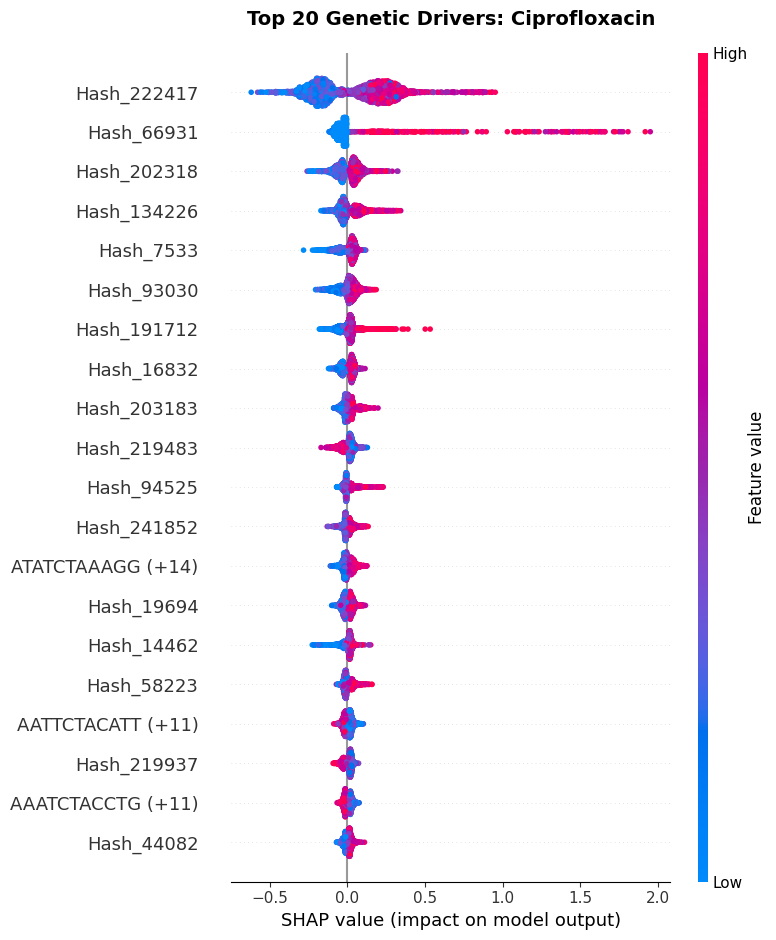

   ✅ Saved plots to /kaggle/working/SHAP_Plots

📊 PLOTTING: MEROPENEM
   ➤ Calculating SHAP values...
   ➤ Calculating SHAP values...
   ➤ Mapping recovered DNA to plot labels...
   ➤ Rendering high-resolution plot...


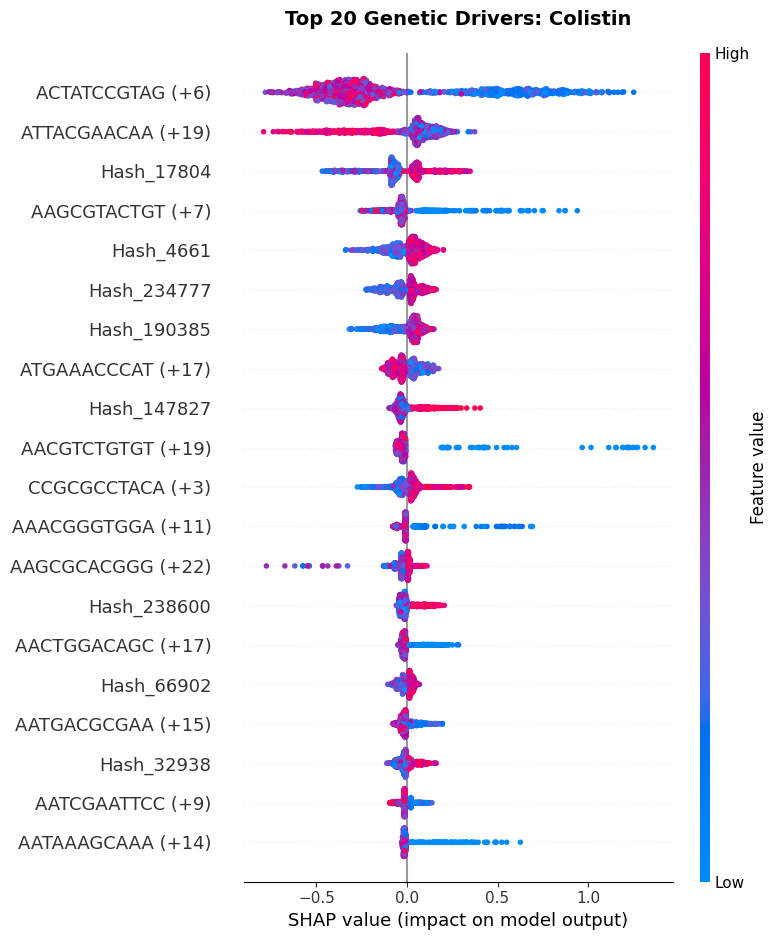

   ✅ Saved plots to /kaggle/working/SHAP_Plots

🏁 SHAP VISUALIZATION COMPLETE.


In [6]:
# ==============================================================================
# STAGE 7 VISUALIZATION: Global SHAP Summary Plots with DNA Text
# ==============================================================================
import os
import numpy as np
import pandas as pd
import scipy.sparse
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

# --- PATHS ---
INPUT_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-aware-top-5000-better"
TRANSLATED_DIR = "/kaggle/input/datasets/muskan12345678910/final-genes-translated"
OUTPUT_DIR = "/kaggle/working/SHAP_Plots"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DRUGS = ["ciprofloxacin", "meropenem", "colistin"] 
BREAKPOINTS = {"meropenem": 8.0, "ciprofloxacin": 0.5, "colistin": 2.0}

# --- WEIGHTING ENGINES ---
def balance_training_data(X_train, y_train, limit, ratio=1.0):
    res_idx = np.where(y_train > limit)[0]
    sus_idx = np.where(y_train <= limit)[0]
    if len(sus_idx) > len(res_idx):
        np.random.seed(42)
        sus_idx = np.random.choice(sus_idx, size=int(len(res_idx)*ratio), replace=False)
    balanced_idx = np.concatenate([res_idx, sus_idx])
    np.random.shuffle(balanced_idx)
    return X_train[balanced_idx], y_train[balanced_idx]

def get_class_weights(y_train, limit):
    is_res = y_train > limit
    n_total = len(y_train)
    n_res, n_sus = np.sum(is_res), n_total - np.sum(is_res)
    w_res = n_total / (2 * n_res) if n_res > 0 else 1.0
    w_sus = n_total / (2 * n_sus) if n_sus > 0 else 1.0
    weights = np.where(is_res, w_res, w_sus)
    return weights / np.mean(weights)

def get_breakpoint_weights(y_train, limit):
    dist = np.abs(y_train - limit)
    weights = np.ones_like(y_train)
    weights[dist <= 1.0] *= 5.0
    weights[(dist > 1.0) & (dist <= 2.0)] *= 2.0
    return weights / np.mean(weights)

print("🎨 STARTING SHAP VISUALIZATION...")

for drug in DRUGS:
    print(f"\n{'='*50}\n📊 PLOTTING: {drug.upper()}\n{'='*50}")
    try:
        # 1. Load Data
        X_pure = scipy.sparse.load_npz(f"{INPUT_DIR}/X_{drug}_top5000_lineage_aware.npz")
        y_true = np.load(f"{INPUT_DIR}/y_mic_{drug}.npy")
        top_5000_map = np.load(f"{INPUT_DIR}/top_5000_idx_{drug}.npy")
        limit = np.log2(BREAKPOINTS[drug])
        
        # 2. Rebuild the precise model
        model = xgb.XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.03, 
            tree_method='hist', device='cpu', random_state=42
        )
        
        if drug == "ciprofloxacin":
            weights = get_breakpoint_weights(y_true, limit)
            model.fit(X_pure, y_true, sample_weight=weights)
        elif drug == "meropenem":
            weights = get_class_weights(y_true, limit)
            model.fit(X_pure, y_true, sample_weight=weights)
        elif drug == "colistin":
            X_bal, y_bal = balance_training_data(X_pure, y_true, limit)
            model.fit(X_bal, y_bal)
            
        # 3. Native SHAP Calculation
        print("   ➤ Calculating SHAP values...")
        dtrain = xgb.DMatrix(X_pure)
        shap_contribs = model.get_booster().predict(dtrain, pred_contribs=True)
        shap_values = shap_contribs[:, :-1] # Drop the bias column
        
        # 4. Map translated DNA strings to feature names
        print("   ➤ Mapping recovered DNA to plot labels...")
        hash_to_dna = {}
        trans_file = f"{TRANSLATED_DIR}/top_20_translated_{drug}.csv"
        
        if os.path.exists(trans_file):
            df_trans = pd.read_csv(trans_file)
            for _, row in df_trans.iterrows():
                dna_strings = str(row['Recovered_11_mers']).split('|')
                # Take the first DNA string. If it's a collision, tag it.
                display_name = dna_strings[0] if len(dna_strings) == 1 else f"{dna_strings[0]} (+{len(dna_strings)-1})"
                hash_to_dna[row['Global_Hash_Index']] = display_name
                
        # Generate the list of 5,000 feature names
        feature_names = [
            hash_to_dna.get(h, f"Hash_{h}") for h in top_5000_map
        ]
        
        # 5. Generate and Save the Plot
        print(f"   ➤ Rendering high-resolution plot...")
        plt.figure(figsize=(10, 8))
        
        # Convert sparse matrix to dense array for smooth plotting
        X_dense = X_pure.toarray()
        
        # Generate beeswarm plot
        shap.summary_plot(
            shap_values, 
            X_dense, 
            feature_names=feature_names, 
            max_display=20, 
            show=False # Prevent immediate rendering so we can save it
        )
        
        # Formatting for manuscript
        plt.title(f"Top 20 Genetic Drivers: {drug.capitalize()}", fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        
        # Save as PNG (for Kaggle viewing) and PDF (for journal submission)
        png_path = f"{OUTPUT_DIR}/shap_summary_{drug}.png"
        pdf_path = f"{OUTPUT_DIR}/shap_summary_{drug}.pdf"
        plt.savefig(png_path, dpi=300, bbox_inches='tight')
        plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
        
        plt.show() # Display in notebook
        plt.close()
        
        print(f"   ✅ Saved plots to {OUTPUT_DIR}")
        
    except Exception as e:
        print(f"❌ Error plotting {drug}: {e}")

print("\n🏁 SHAP VISUALIZATION COMPLETE.")

📊 SHAP PLOTS

CIPROFLOXACIN


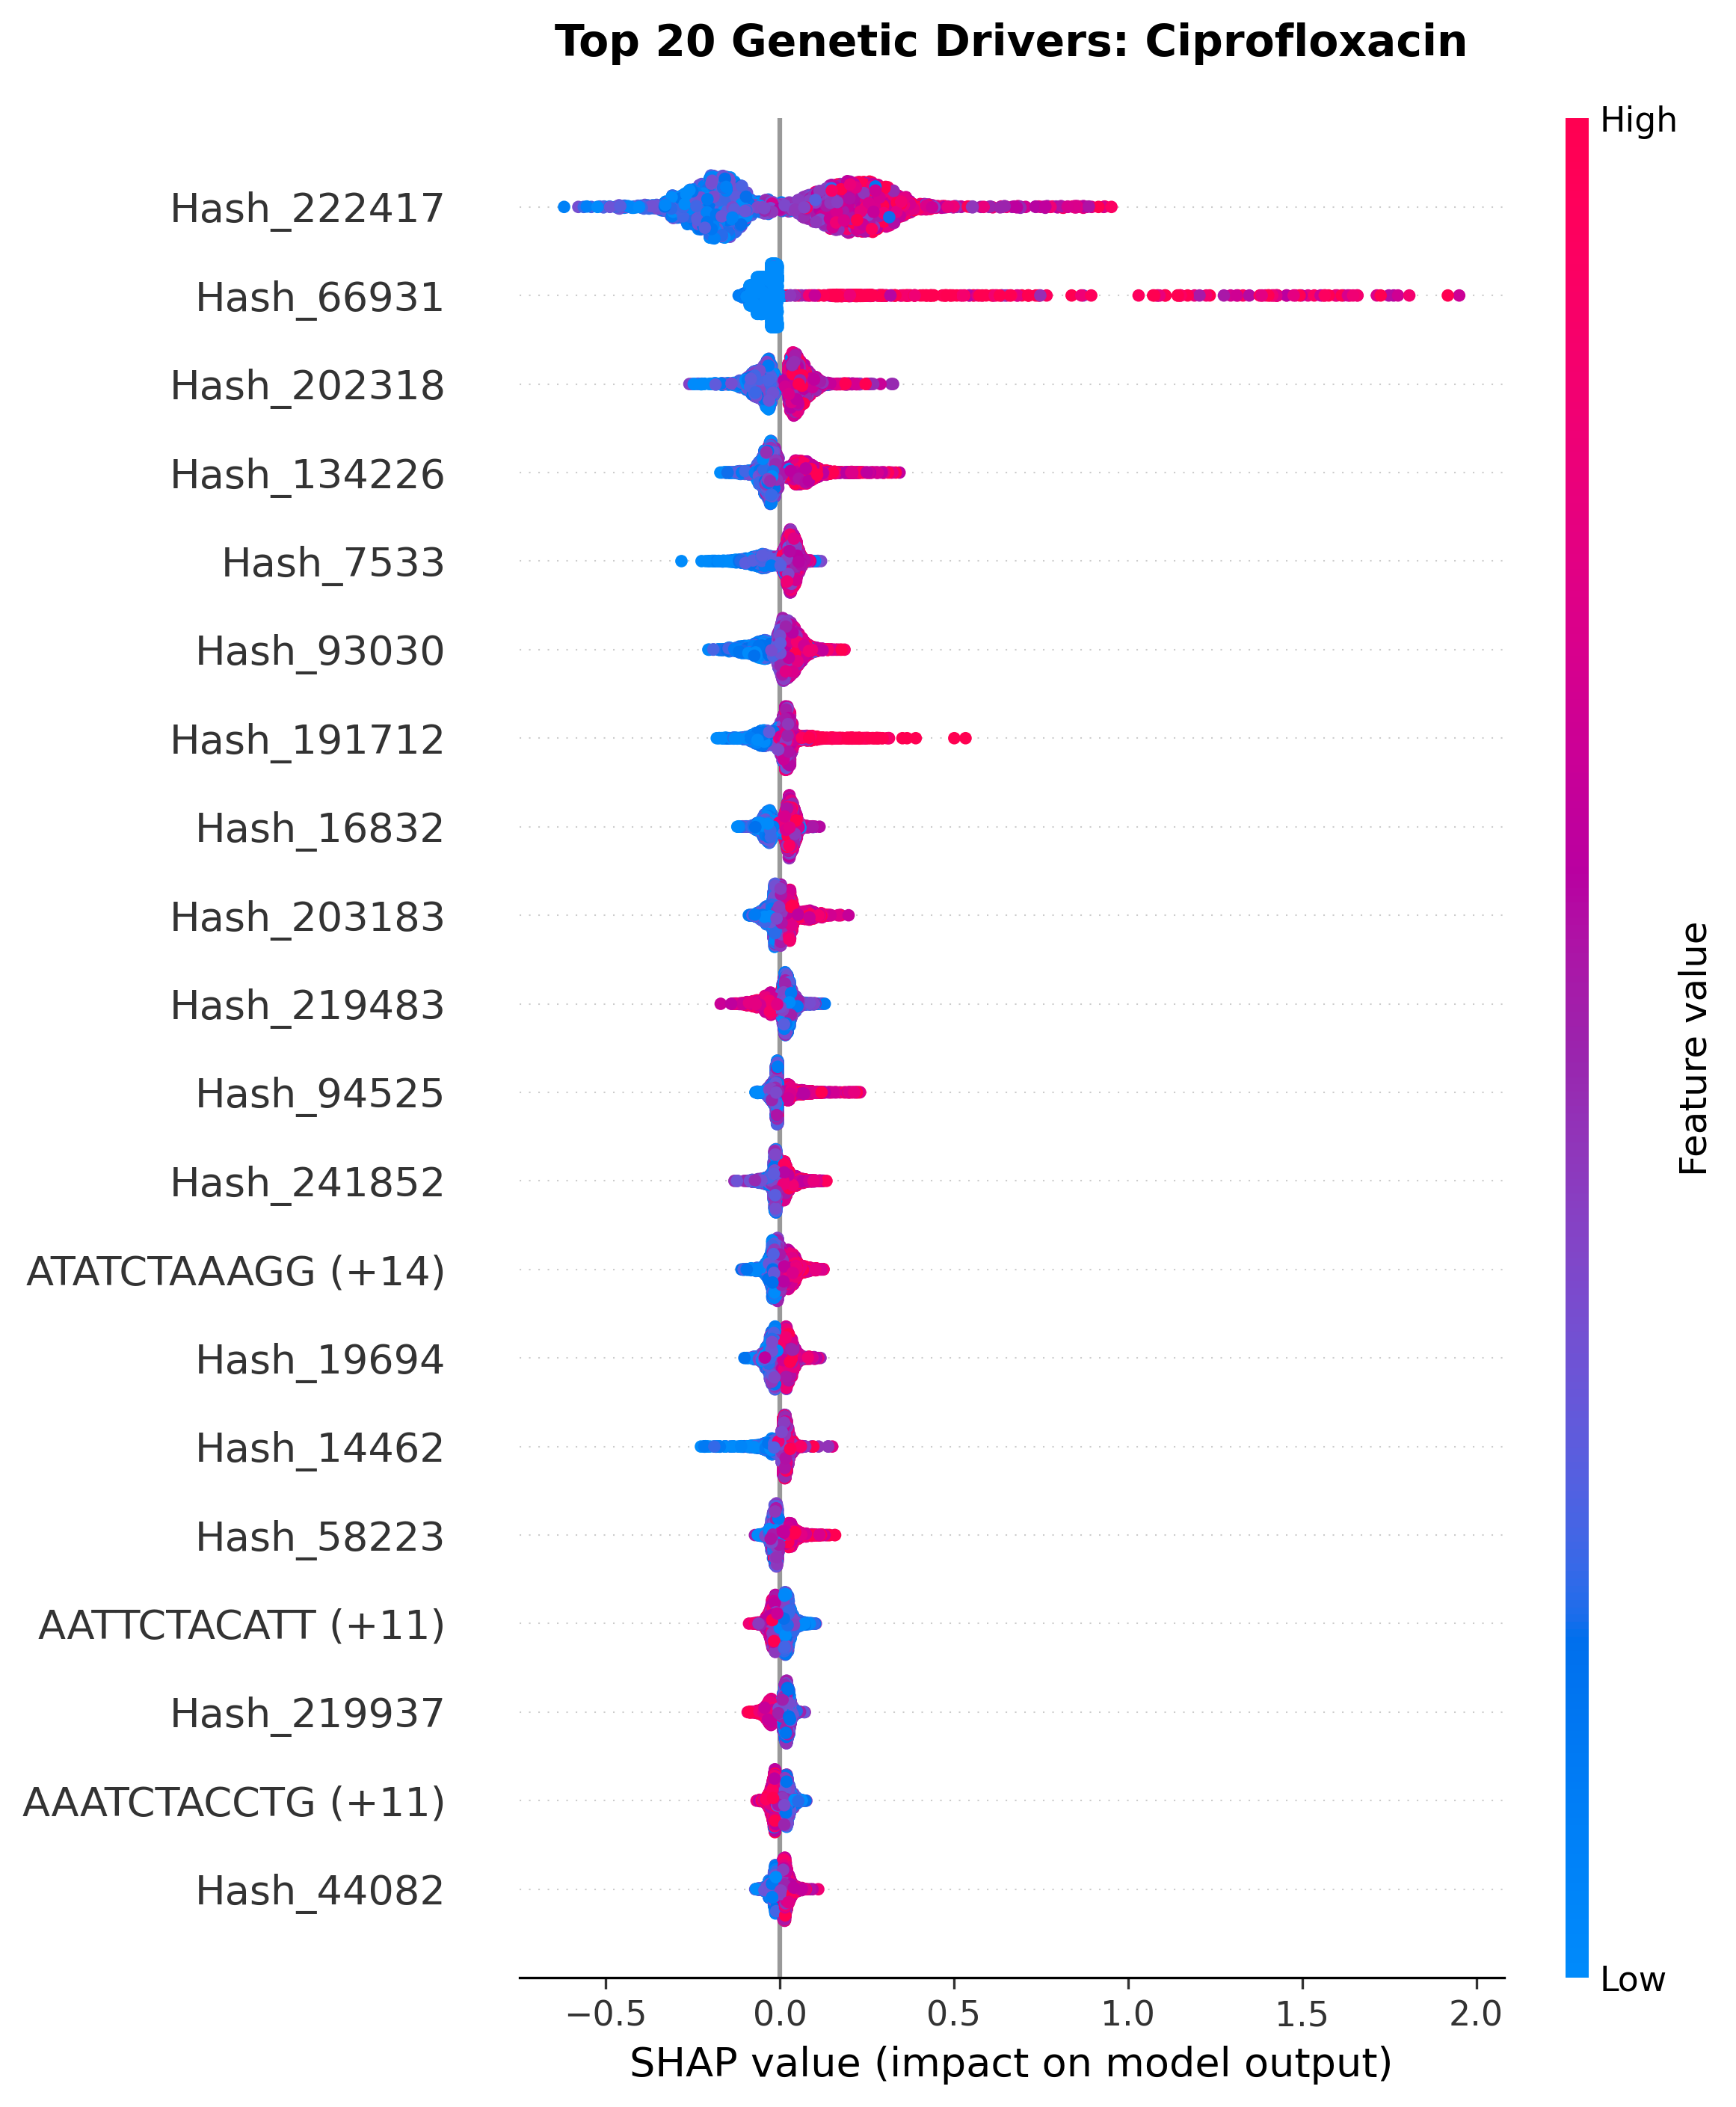


MEROPENEM


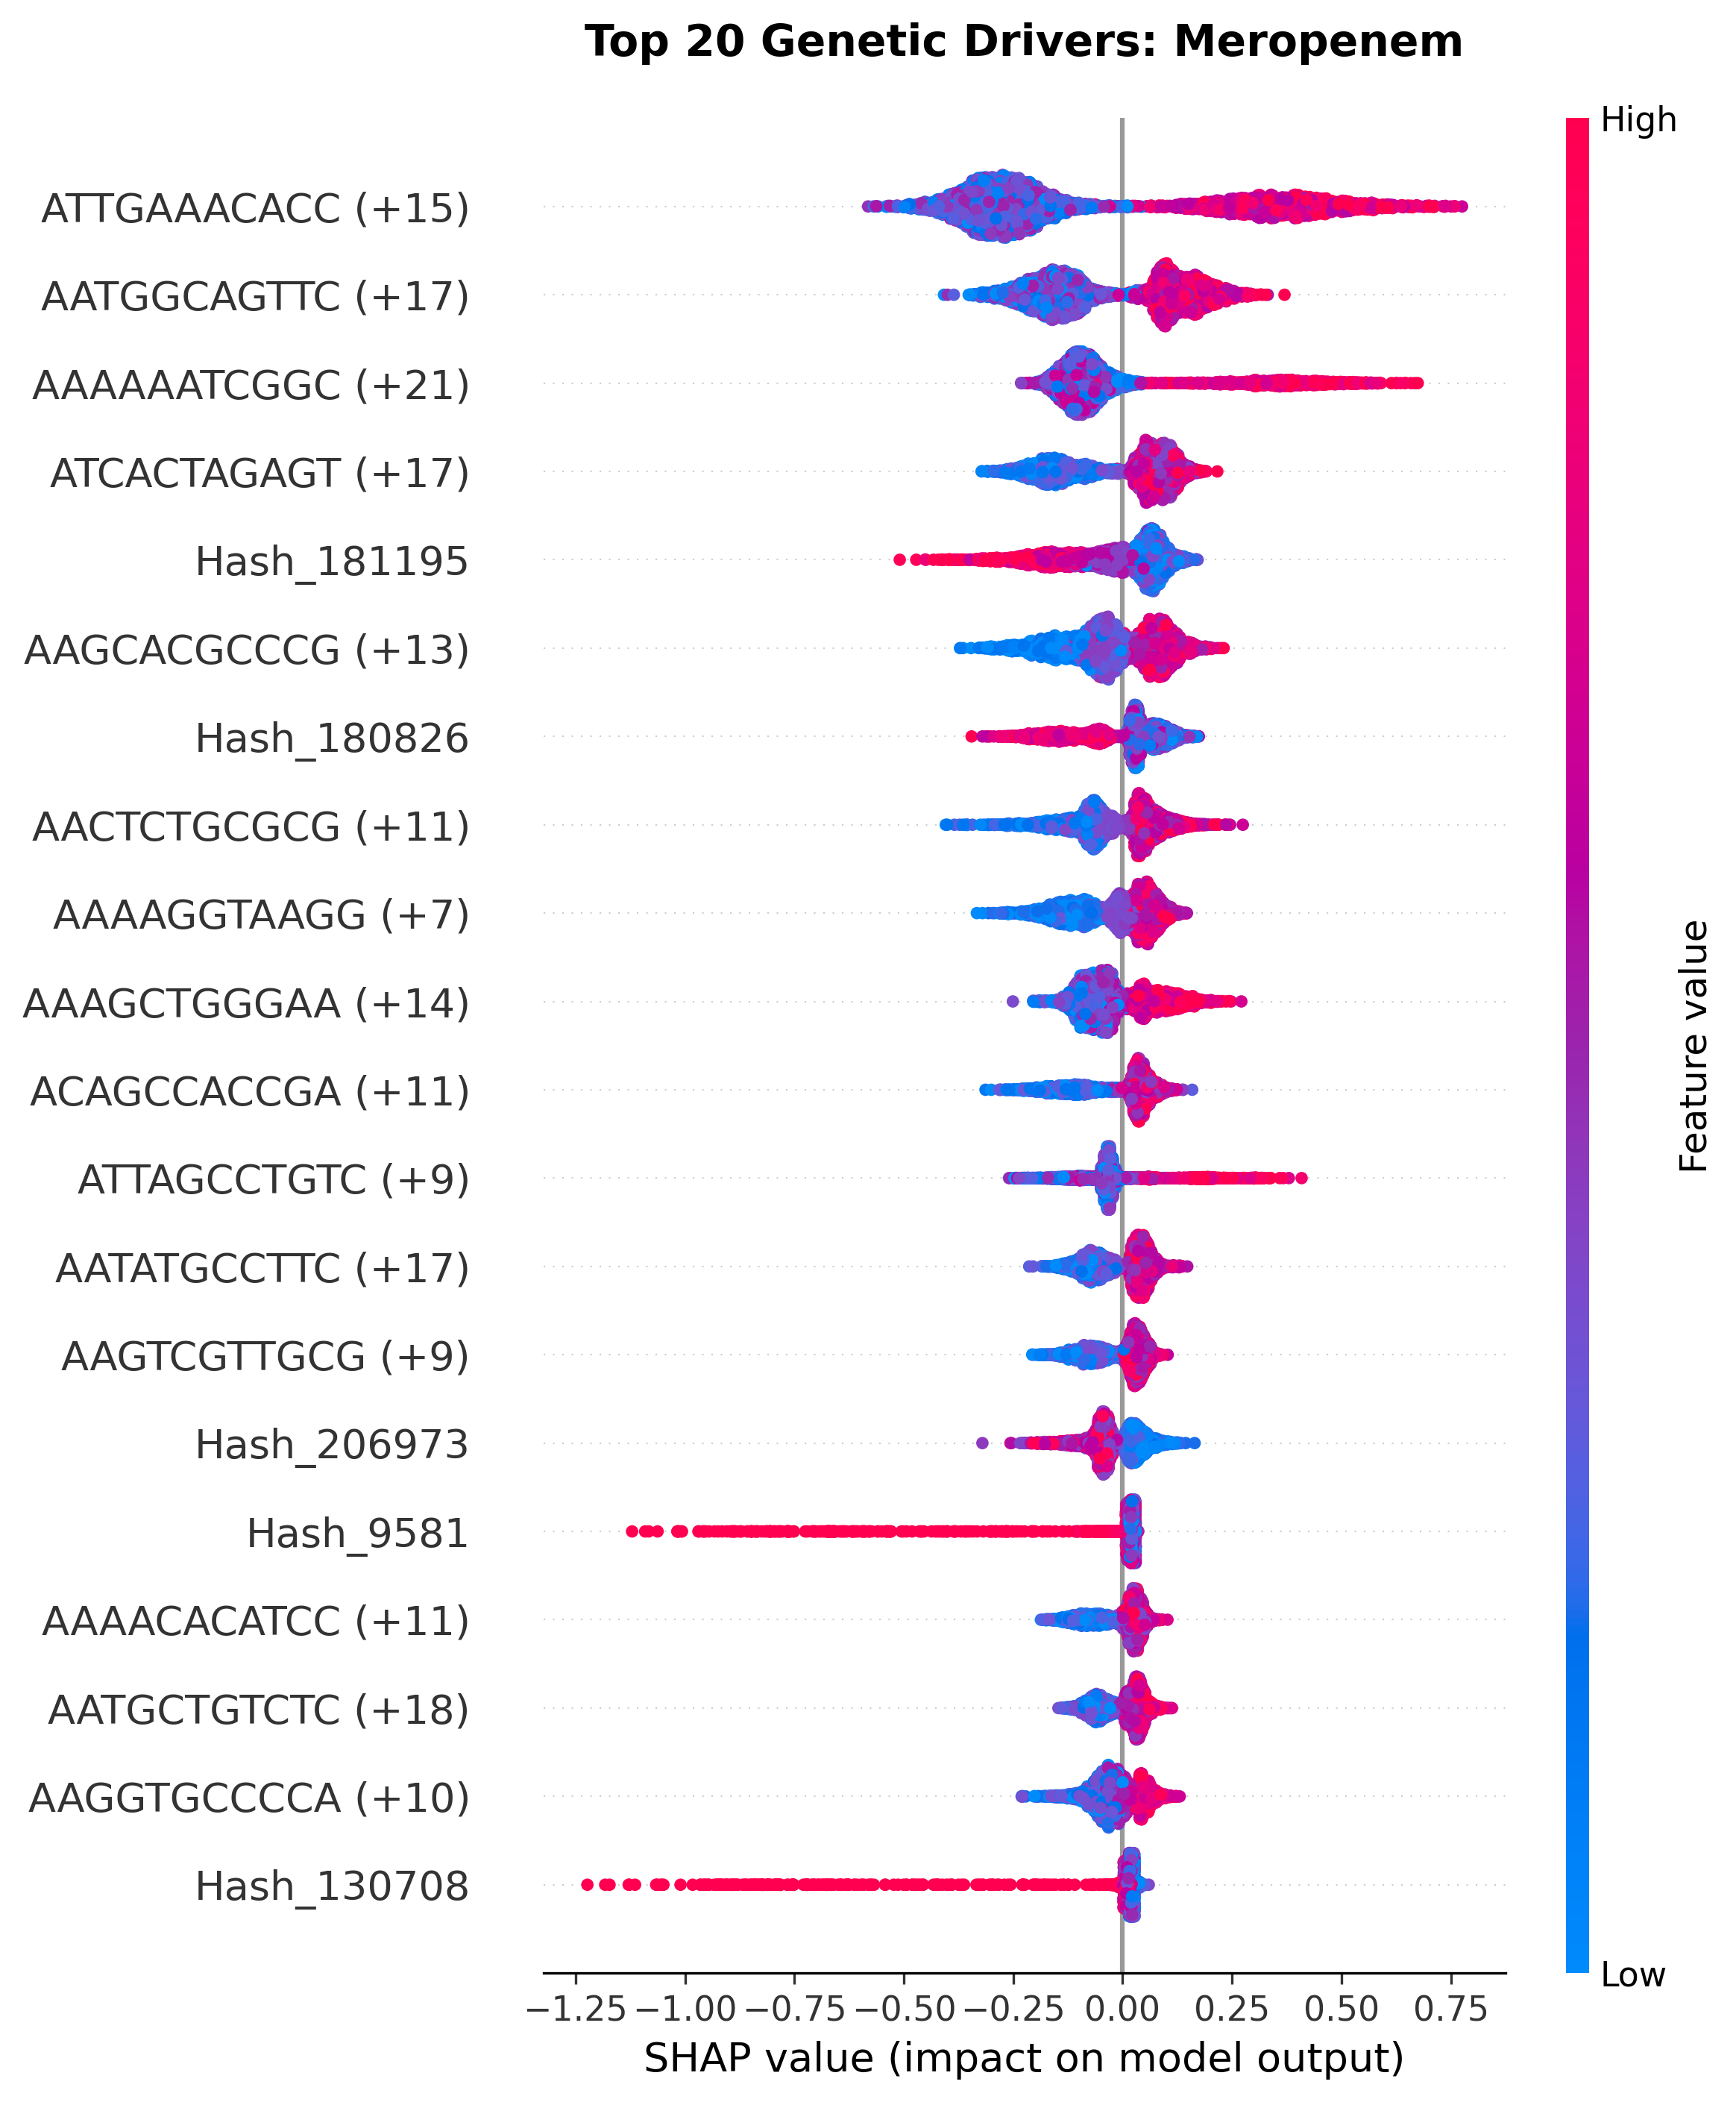


COLISTIN


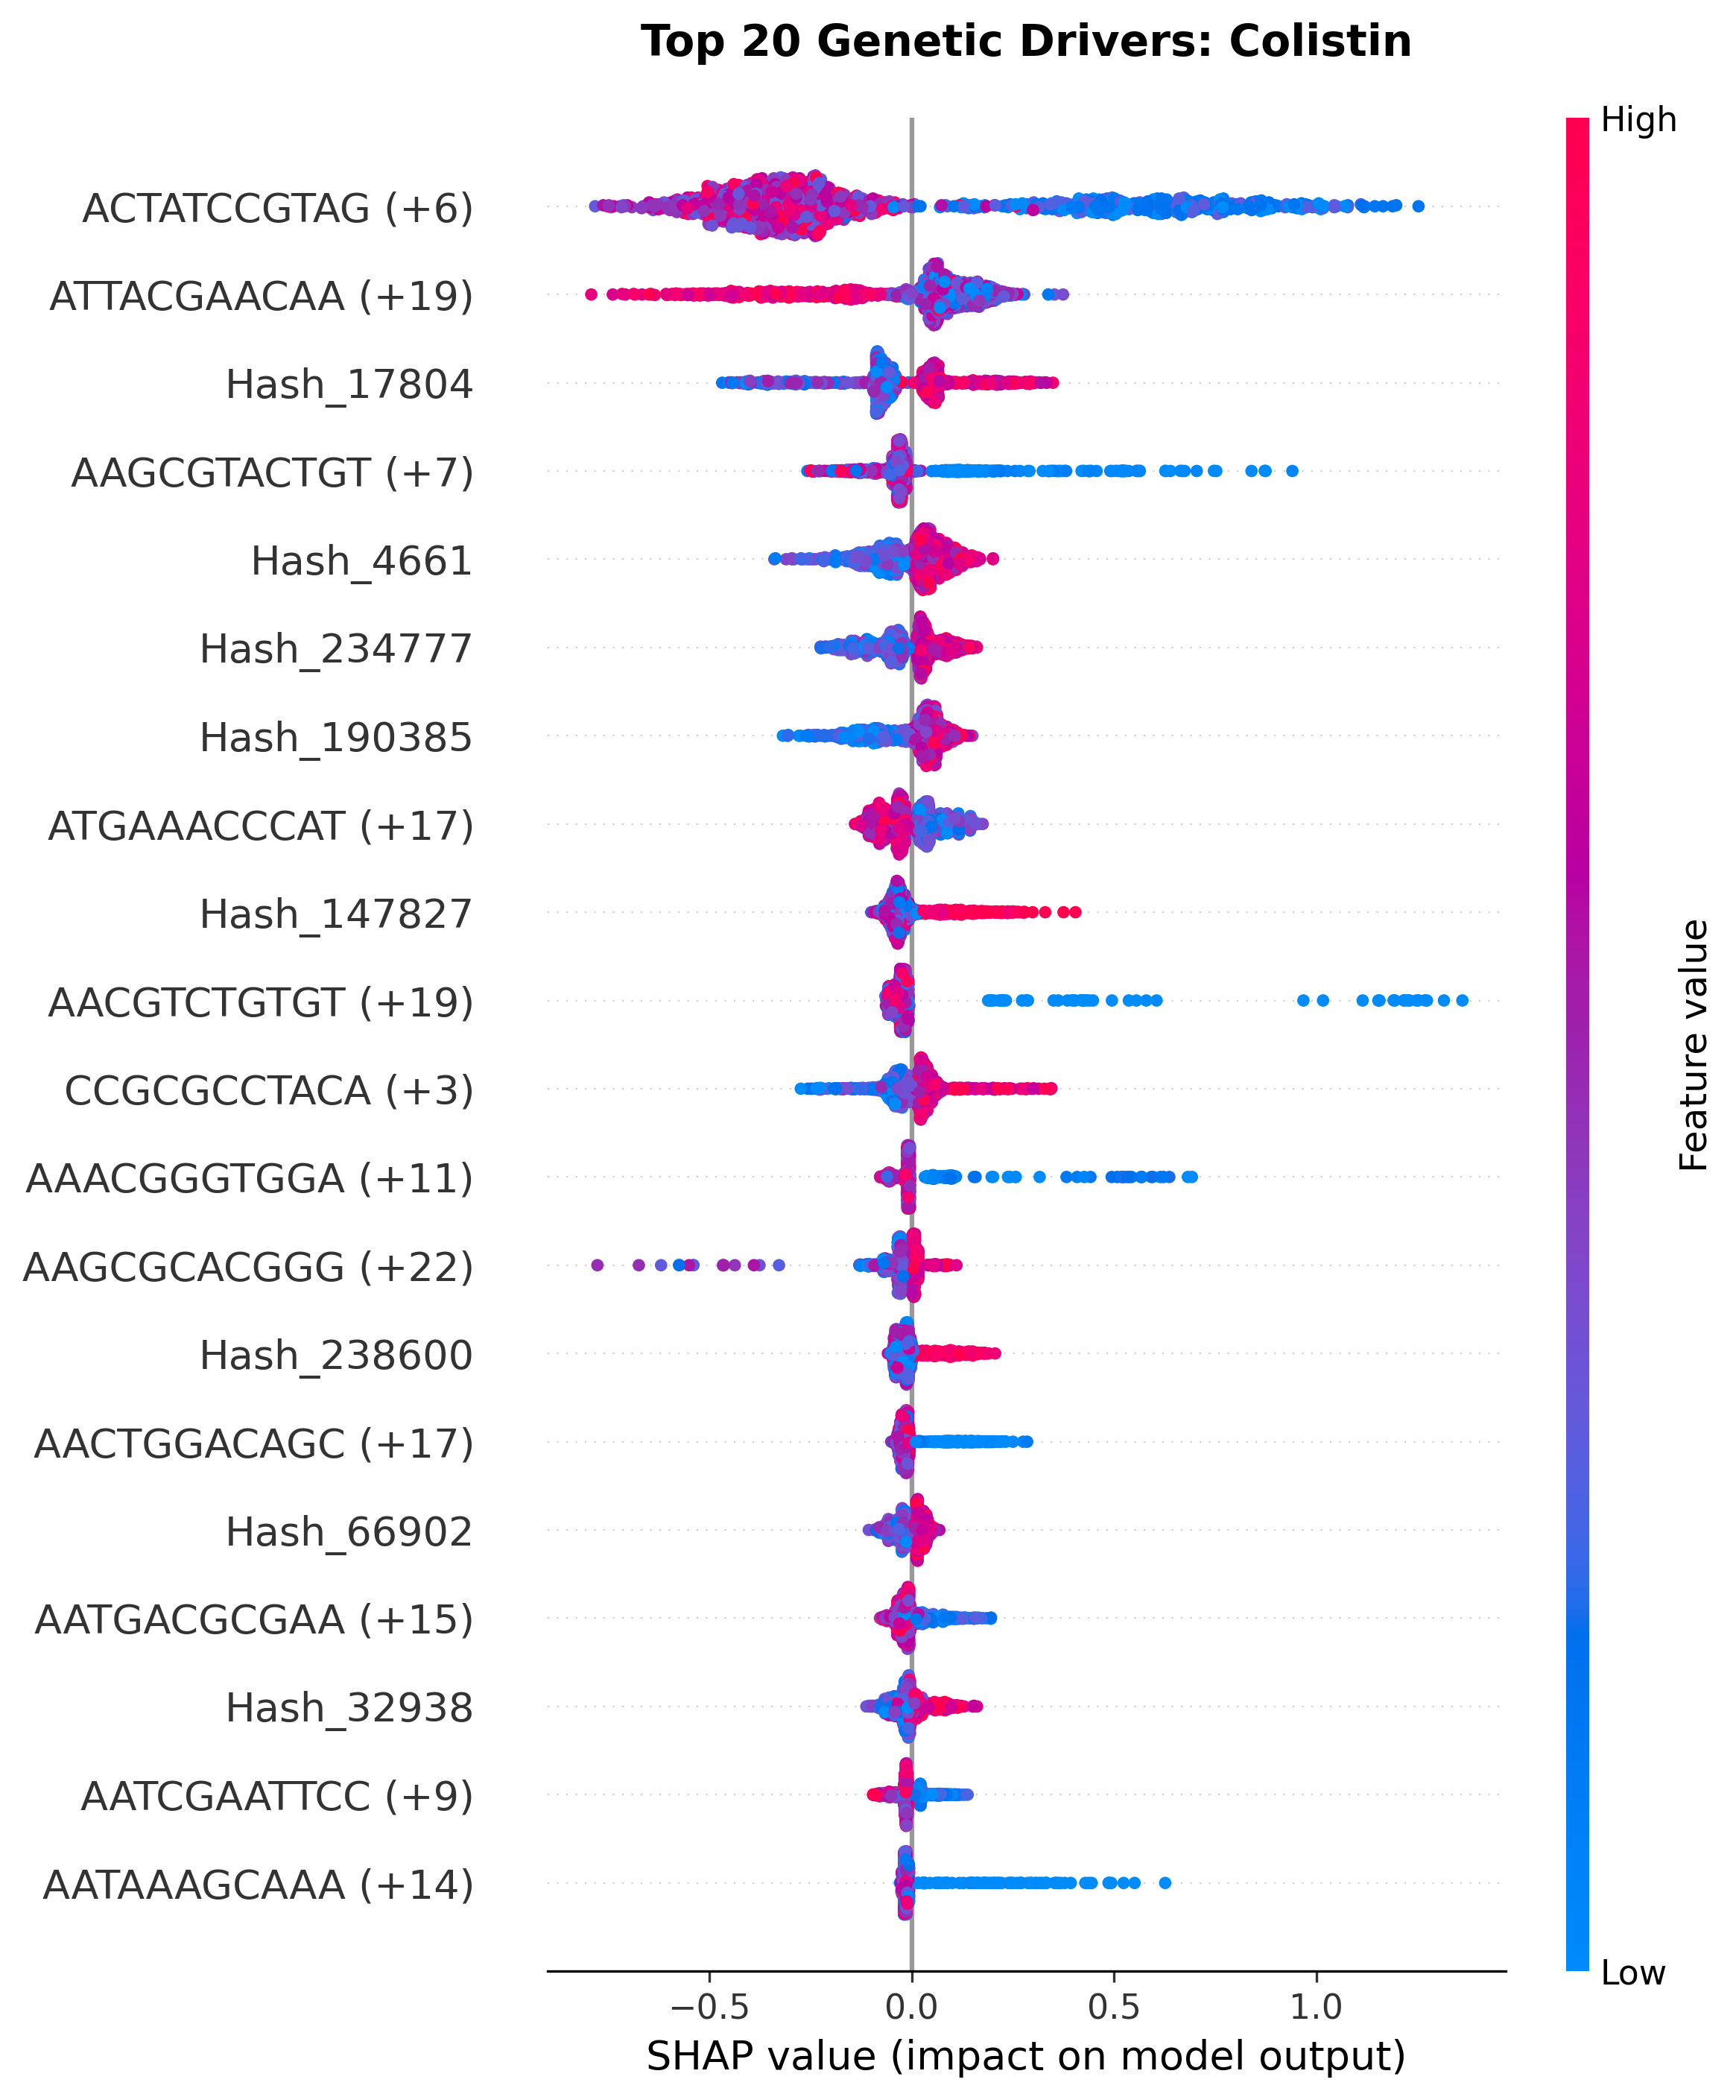

In [7]:
# ==============================================================================
# STAGE 8: DISPLAY SAVED SHAP PLOTS
# ==============================================================================

from IPython.display import display, Image
import os

OUTPUT_DIR = "/kaggle/working/SHAP_Plots"

DRUGS = ["ciprofloxacin", "meropenem", "colistin"]

print("📊 SHAP PLOTS")
print("=" * 60)

for drug in DRUGS:
    png_path = f"{OUTPUT_DIR}/shap_summary_{drug}.png"
    
    if os.path.exists(png_path):
        print(f"\n{drug.upper()}")
        display(Image(filename=png_path))
    else:
        print(f"❌ Plot not found: {png_path}")

In [ ]:
# ==============================================================================
# STAGE 9: EXTRACT TOP 20 SHAP FEATURES + SHAP IMPORTANCE
# ==============================================================================

import os
import numpy as np
import pandas as pd
import scipy.sparse
import xgboost as xgb

INPUT_DIR = "/kaggle/input/datasets/muskan12345678910/lineage-aware-top-5000-better"
TRANSLATED_DIR = "/kaggle/input/datasets/muskan12345678910/final-genes-translated"
OUTPUT_DIR = "/kaggle/working/SHAP_Plots"

DRUGS = ["ciprofloxacin", "meropenem", "colistin"]

all_top_features = {}

for drug in DRUGS:

    print(f"\n{'='*60}")
    print(f"🔬 EXTRACTING TOP SHAP FEATURES: {drug.upper()}")
    print(f"{'='*60}")

    # ----------------------------------------------------------
    # 1. Load feature matrix and mapping
    # ----------------------------------------------------------

    X_pure = scipy.sparse.load_npz(
        f"{INPUT_DIR}/X_{drug}_top5000_lineage_aware.npz"
    )

    top_5000_map = np.load(
        f"{INPUT_DIR}/top_5000_idx_{drug}.npy"
    )

    # ----------------------------------------------------------
    # 2. Rebuild model exactly as in previous cell
    # ----------------------------------------------------------

    y_true = np.load(
        f"{INPUT_DIR}/y_mic_{drug}.npy"
    )

    BREAKPOINTS = {
        "meropenem": 8.0,
        "ciprofloxacin": 0.5,
        "colistin": 2.0
    }

    limit = np.log2(BREAKPOINTS[drug])

    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.03,
        tree_method="hist",
        device="cpu",
        random_state=42
    )

    # ----------------------------------------------------------
    # 3. Same weighting strategy
    # ----------------------------------------------------------

    def balance_training_data(X_train, y_train, limit, ratio=1.0):
        res_idx = np.where(y_train > limit)[0]
        sus_idx = np.where(y_train <= limit)[0]

        if len(sus_idx) > len(res_idx):
            np.random.seed(42)
            sus_idx = np.random.choice(
                sus_idx,
                size=int(len(res_idx) * ratio),
                replace=False
            )

        balanced_idx = np.concatenate([res_idx, sus_idx])
        np.random.shuffle(balanced_idx)

        return X_train[balanced_idx], y_train[balanced_idx]

    def get_class_weights(y_train, limit):

        is_res = y_train > limit

        n_total = len(y_train)
        n_res = np.sum(is_res)
        n_sus = n_total - n_res

        w_res = n_total / (2 * n_res) if n_res > 0 else 1.0
        w_sus = n_total / (2 * n_sus) if n_sus > 0 else 1.0

        weights = np.where(is_res, w_res, w_sus)

        return weights / np.mean(weights)

    def get_breakpoint_weights(y_train, limit):

        dist = np.abs(y_train - limit)

        weights = np.ones_like(y_train)

        weights[dist <= 1.0] *= 5.0
        weights[(dist > 1.0) & (dist <= 2.0)] *= 2.0

        return weights / np.mean(weights)

    if drug == "ciprofloxacin":

        weights = get_breakpoint_weights(y_true, limit)

        model.fit(
            X_pure,
            y_true,
            sample_weight=weights
        )

    elif drug == "meropenem":

        weights = get_class_weights(y_true, limit)

        model.fit(
            X_pure,
            y_true,
            sample_weight=weights
        )

    elif drug == "colistin":

        X_bal, y_bal = balance_training_data(
            X_pure,
            y_true,
            limit
        )

        model.fit(
            X_bal,
            y_bal
        )

    # ----------------------------------------------------------
    # 4. Calculate SHAP
    # ----------------------------------------------------------

    dtrain = xgb.DMatrix(X_pure)

    shap_contribs = model.get_booster().predict(
        dtrain,
        pred_contribs=True
    )

    shap_values = shap_contribs[:, :-1]

    # ----------------------------------------------------------
    # 5. Recover DNA labels
    # ----------------------------------------------------------

    hash_to_dna = {}

    trans_file = (
        f"{TRANSLATED_DIR}/top_20_translated_{drug}.csv"
    )

    if os.path.exists(trans_file):

        df_trans = pd.read_csv(trans_file)

        for _, row in df_trans.iterrows():

            dna_strings = str(
                row["Recovered_11_mers"]
            ).split("|")

            if len(dna_strings) == 1:

                display_name = dna_strings[0]

            else:

                display_name = (
                    f"{dna_strings[0]} "
                    f"(+{len(dna_strings)-1})"
                )

            hash_to_dna[
                row["Global_Hash_Index"]
            ] = display_name

    # ----------------------------------------------------------
    # 6. Create feature names
    # ----------------------------------------------------------

    feature_names = [
        hash_to_dna.get(
            h,
            f"Hash_{h}"
        )
        for h in top_5000_map
    ]

    # ----------------------------------------------------------
    # 7. Calculate mean |SHAP|
    # ----------------------------------------------------------

    mean_abs_shap = np.mean(
        np.abs(shap_values),
        axis=0
    )

    mean_shap = np.mean(
        shap_values,
        axis=0
    )

    # ----------------------------------------------------------
    # 8. Build table
    # ----------------------------------------------------------

    results = pd.DataFrame({

        "Feature_Rank": np.arange(
            1,
            len(feature_names) + 1
        ),

        "Feature": feature_names,

        "Mean_Absolute_SHAP": mean_abs_shap,

        "Mean_SHAP": mean_shap,

        "Global_Hash_Index": top_5000_map

    })

    # Sort by importance

    results = results.sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    ).reset_index(drop=True)

    results["Feature_Rank"] = np.arange(
        1,
        len(results) + 1
    )

    # ----------------------------------------------------------
    # 9. Top 20
    # ----------------------------------------------------------

    top20 = results.head(20)

    all_top_features[drug] = top20

    print("\nTOP 20 FEATURES:\n")

    display(top20)

    # ----------------------------------------------------------
    # 10. Save CSV
    # ----------------------------------------------------------

    output_file = (
        f"{OUTPUT_DIR}/"
        f"{drug}_Top20_SHAP_features.csv"
    )

    top20.to_csv(
        output_file,
        index=False
    )

    print(
        f"\n✅ Saved: {output_file}"
    )

print("\n🏁 TOP FEATURE EXTRACTION COMPLETE")

In [ ]:
# ==============================================================================
# STAGE 9 (ULTRA-FAST): O(1) Sliding Window & Raw I/O
# ==============================================================================
import pandas as pd
import os
import concurrent.futures
from functools import partial
from tqdm.auto import tqdm

# --- PATHS ---
FASTA_DIR = "/kaggle/input/datasets/muskan12345678910/klebsiella-amr-genomes-v1"
FEATURES_DIR = "/kaggle/input/datasets/muskan12345678910/final-genes-translated"
OUTPUT_DIR = "/kaggle/working/CARD_Ready_FASTA"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DRUGS = ["ciprofloxacin", "meropenem", "colistin"]
FLANK_SIZE = 100
KMER_LEN = 11

def reverse_complement(seq):
    trans = str.maketrans('ATCG', 'TAGC')
    return seq.translate(trans)[::-1]

# --- SLIDING WINDOW WORKER ---
def process_genome_sliding_window(filename, fasta_dir, target_metadata, flank_size, kmer_len):
    genome_path = os.path.join(fasta_dir, filename)
    genome_id = filename.split('.')[0]
    local_records = []
    
    try:
        # 1. Ultra-fast raw file reading (bypassing BioPython overhead)
        with open(genome_path, 'r') as f:
            sequence = "".join(line.strip().upper() for line in f if not line.startswith(">"))
            
        seq_len = len(sequence)
        
        # 2. O(1) Lookup Set
        target_set = set(target_metadata.keys())
        local_hit_counts = {k: 0 for k in target_set}
        
        # 3. Single-pass Sliding Window
        for i in range(seq_len - kmer_len + 1):
            window = sequence[i:i+kmer_len]
            
            # Instant dictionary lookup
            if window in target_set:
                local_hit_counts[window] += 1
                meta = target_metadata[window]
                
                # Extract flanks
                start_extract = max(0, i - flank_size)
                end_extract = min(seq_len, i + kmer_len + flank_size)
                flanked_seq = sequence[start_extract:end_extract]
                
                # Tag includes multi-hit counter
                header = f">{genome_id}_Hash{meta['hash']}_{meta['original_kmer']}_loc{local_hit_counts[window]}_{meta['strand']}"
                local_records.append(f"{header}\n{flanked_seq}\n")
                
    except Exception:
        pass # Skip corrupted files safely
        
    return local_records

print("🚀 STARTING O(1) SLIDING WINDOW EXTRACTION...")
num_cores = os.cpu_count() or 2
print(f"⚡ Utilizing {num_cores} CPU cores...")

for drug in DRUGS:
    print(f"\n{'='*50}\n🔍 EXTRACTING: {drug.upper()}\n{'='*50}")
    
    df = pd.read_csv(f"{FEATURES_DIR}/top_20_translated_{drug}.csv")
    target_metadata = {}
    
    # 1. Build the fast-lookup dictionary
    for _, row in df.iterrows():
        hash_idx = row['Global_Hash_Index']
        recovered_strings = str(row['Recovered_11_mers']).split('|')
        
        if recovered_strings[0] == "NOT_FOUND":
            continue
            
        for kmer in recovered_strings:
            kmer_rc = reverse_complement(kmer)
            target_metadata[kmer] = {'hash': hash_idx, 'original_kmer': kmer, 'strand': 'FWD'}
            target_metadata[kmer_rc] = {'hash': hash_idx, 'original_kmer': kmer, 'strand': 'REV'}
            
    if not target_metadata:
        print(f"⚠️ No sequences to search for {drug}.")
        continue

    # 2. Get list of all genomes
    valid_files = [f for f in os.listdir(FASTA_DIR) if f.endswith(('.fasta', '.fna'))]
    print(f"Scanning {len(valid_files)} genomes for {len(target_metadata)} targets...")
    
    # 3. Execute Parallel Search
    output_records = []
    process_func = partial(
        process_genome_sliding_window, 
        fasta_dir=FASTA_DIR, 
        target_metadata=target_metadata, 
        flank_size=FLANK_SIZE,
        kmer_len=KMER_LEN
    )
    
    with concurrent.futures.ProcessPoolExecutor(max_workers=num_cores) as executor:
        results = list(tqdm(executor.map(process_func, valid_files), total=len(valid_files), desc=f"{drug.upper()} Progress"))
        
    # Flatten results
    for res in results:
        output_records.extend(res)

    # 4. Save to final FASTA
    output_file = f"{OUTPUT_DIR}/drivers_for_analysis_{drug}.fasta"
    if output_records:
        with open(output_file, "w") as f:
            f.writelines(output_records)
        print(f"✅ Generated CARD-ready FASTA: {output_file} ({len(output_records)} sequences anchored)")
    else:
        print(f"⚠️ No matches found.")

print("\n🏁 PIPELINE COMPLETE. You can now download the FASTA files for CARD RGI.")

In [ ]:
# ==============================================================================
# FASTA DEDUPLICATOR: Shrinking Massive Files for Web Alignment
# ==============================================================================
import os

INPUT_DIR = "/kaggle/working/CARD_Ready_FASTA"
OUTPUT_DIR = "/kaggle/working/CARD_Unique_FASTA"
os.makedirs(OUTPUT_DIR, exist_ok=True)

DRUGS = ["ciprofloxacin", "meropenem", "colistin"]

print("🧬 STARTING FASTA DEDUPLICATION...")

for drug in DRUGS:
    input_fasta = f"{INPUT_DIR}/drivers_for_analysis_{drug}.fasta"
    output_fasta = f"{OUTPUT_DIR}/{drug}_unique_targets.fasta"
    
    if not os.path.exists(input_fasta):
        print(f"⚠️ File not found for {drug}. Skipping.")
        continue
        
    print(f"\n{'='*50}\n📉 COMPRESSING: {drug.upper()}\n{'='*50}")
    
    seen_sequences = set()
    total_count = 0
    unique_count = 0
    
    # Fast file parsing
    with open(input_fasta, 'r') as fin, open(output_fasta, 'w') as fout:
        header = ""
        seq_blocks = []
        
        for line in fin:
            line = line.strip()
            if line.startswith(">"):
                if header:
                    full_seq = "".join(seq_blocks)
                    total_count += 1
                    
                    if full_seq not in seen_sequences:
                        seen_sequences.add(full_seq)
                        fout.write(f"{header}\n{full_seq}\n")
                        unique_count += 1
                        
                header = line
                seq_blocks = []
            else:
                seq_blocks.append(line)
                
        # Catch the very last sequence in the file
        if header:
            full_seq = "".join(seq_blocks)
            total_count += 1
            if full_seq not in seen_sequences:
                seen_sequences.add(full_seq)
                fout.write(f"{header}\n{full_seq}\n")
                unique_count += 1

    reduction_percent = 100 - ((unique_count / total_count) * 100) if total_count > 0 else 0
    print(f"   Original Sequences: {total_count:,}")
    print(f"   Unique Sequences:   {unique_count:,}")
    print(f"   ✅ Redundancy reduced by {reduction_percent:.2f}%")
    print(f"   💾 Saved clean file to: {output_fasta}")

print("\n🏁 DEDUPLICATION COMPLETE.")

In [ ]:
# ==============================================================================   colistin
# STAGE 10: Full-Genome Alignment for Novel Target Discovery
# ==============================================================================

# 1. Install NCBI BLAST+ 
!apt-get update > /dev/null
!apt-get install ncbi-blast+ -y > /dev/null
print("✅ NCBI BLAST+ Installed")

# 2. Download the complete K. pneumoniae Reference Genome (RefSeq)
!wget -q https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/240/185/GCF_000240185.1_ASM24018v2/GCF_000240185.1_ASM24018v2_genomic.fna.gz -O k_pneu_reference.fna.gz
!gunzip k_pneu_reference.fna.gz
print("✅ Reference Genome Downloaded")

# 3. Compile the Reference Genome into a BLAST Database
!makeblastdb -in k_pneu_reference.fna -dbtype nucl -out KPNEU_DB > /dev/null
print("✅ Full-Genome Database Compiled")

# Execute High-Speed BLAST Alignment for Colistin
!blastn -query "/kaggle/input/datasets/muskan12345678910/211-flanking-fastas/colistin_unique_targets (1).fasta" \
        -db KPNEU_DB \
        -max_target_seqs 1 \
        -evalue 1e-10 \
        -outfmt "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore" \
        -out /kaggle/working/colistin_novel_discovery_results.tsv

print("🏁 NOVEL TARGET MAPPING COMPLETE! Results saved.")

In [ ]:
# ==============================================================================
# STAGE 11: Mapping Genomic Coordinates to English Gene Names
# ==============================================================================
import urllib.request
import gzip
import pandas as pd
import os

print("🧬 DOWNLOADING GENOME ANNOTATIONS (GFF)...")
gff_url = "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/240/185/GCF_000240185.1_ASM24018v2/GCF_000240185.1_ASM24018v2_genomic.gff.gz"
urllib.request.urlretrieve(gff_url, "/kaggle/working/reference.gff.gz")

print("📖 PARSING ANNOTATIONS...")
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
gff_data = []
with gzip.open("/kaggle/working/reference.gff.gz", "rt") as f:
    for line in f:
        if line.startswith("#"): continue
        parts = line.strip().split("\t")
        if len(parts) == 9 and parts[2] == "CDS": # Only Coding Sequences (Genes)
            gff_data.append(parts)

gff_df = pd.DataFrame(gff_data, columns=gff_cols)
gff_df['start'] = gff_df['start'].astype(int)
gff_df['end'] = gff_df['end'].astype(int)

# Extract Gene Name or Protein Product from the attributes column
def extract_gene_name(attr_string):
    attr_dict = {a.split('=')[0]:a.split('=')[1] for a in attr_string.split(';') if '=' in a}
    return attr_dict.get('gene', attr_dict.get('product', 'Hypothetical Protein'))

gff_df['Gene_Name'] = gff_df['attributes'].apply(extract_gene_name)

print("🔗 MAPPING BLAST COORDINATES TO GENE NAMES...")
# Load the raw BLAST results
cols = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"]
blast_df = pd.read_csv("/kaggle/working/colistin_novel_discovery_results.tsv", sep="\t", header=None, names=cols)

# Create a Hash Index column so we can easily link back to your Top 20 SHAP CSV
blast_df['Hash_Index'] = blast_df['qseqid'].apply(lambda x: x.split('_')[1].replace('Hash', '') if '_' in x else x)

# Find the overlapping gene for each sequence coordinate
def get_gene(row):
    pos_start = min(row['sstart'], row['send'])
    pos_end = max(row['sstart'], row['send'])
    
    overlaps = gff_df[(gff_df['seqid'] == row['sseqid']) & 
                      (gff_df['end'] >= pos_start) & 
                      (gff_df['start'] <= pos_end)]
    
    if len(overlaps) == 0:
        return "Intergenic (Non-coding)"
    return " / ".join(overlaps['Gene_Name'].unique())

blast_df['Gene_Name'] = blast_df.apply(get_gene, axis=1)

# Save the beautifully mapped output
output_path = "/kaggle/working/colistin_mapped_genes.csv"
blast_df[['qseqid', 'Hash_Index', 'sseqid', 'pident', 'Gene_Name']].to_csv(output_path, index=False)

print(f"✅ COMPLETE! Mapped gene names saved to: {output_path}")

In [ ]:
# ==============================================================================   cipro
# STAGE 10: Full-Genome Alignment for Novel Target Discovery
# ==============================================================================

# 1. Install NCBI BLAST+ 
!apt-get update > /dev/null
!apt-get install ncbi-blast+ -y > /dev/null
print("✅ NCBI BLAST+ Installed")

# 2. Download the complete K. pneumoniae Reference Genome (RefSeq)
!wget -q https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/240/185/GCF_000240185.1_ASM24018v2/GCF_000240185.1_ASM24018v2_genomic.fna.gz -O k_pneu_reference.fna.gz
!gunzip k_pneu_reference.fna.gz
print("✅ Reference Genome Downloaded")

# 3. Compile the Reference Genome into a BLAST Database
!makeblastdb -in k_pneu_reference.fna -dbtype nucl -out KPNEU_DB > /dev/null
print("✅ Full-Genome Database Compiled")

# Execute High-Speed BLAST Alignment for Colistin
!blastn -query "/kaggle/input/datasets/muskan12345678910/211-flanking-fastas/ciprofloxacin_unique_targets (1).fasta" \
        -db KPNEU_DB \
        -max_target_seqs 1 \
        -evalue 1e-10 \
        -outfmt "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore" \
        -out /kaggle/working/cipro_novel_discovery_results.tsv

print("🏁 NOVEL TARGET MAPPING COMPLETE! Results saved.")

In [ ]:
# ==============================================================================
# STAGE 11: Mapping Genomic Coordinates to English Gene Names
# ==============================================================================
import urllib.request
import gzip
import pandas as pd
import os

print("🧬 DOWNLOADING GENOME ANNOTATIONS (GFF)...")
gff_url = "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/240/185/GCF_000240185.1_ASM24018v2/GCF_000240185.1_ASM24018v2_genomic.gff.gz"
urllib.request.urlretrieve(gff_url, "/kaggle/working/reference.gff.gz")

print("📖 PARSING ANNOTATIONS...")
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
gff_data = []
with gzip.open("/kaggle/working/reference.gff.gz", "rt") as f:
    for line in f:
        if line.startswith("#"): continue
        parts = line.strip().split("\t")
        if len(parts) == 9 and parts[2] == "CDS": # Only Coding Sequences (Genes)
            gff_data.append(parts)

gff_df = pd.DataFrame(gff_data, columns=gff_cols)
gff_df['start'] = gff_df['start'].astype(int)
gff_df['end'] = gff_df['end'].astype(int)

# Extract Gene Name or Protein Product from the attributes column
def extract_gene_name(attr_string):
    attr_dict = {a.split('=')[0]:a.split('=')[1] for a in attr_string.split(';') if '=' in a}
    return attr_dict.get('gene', attr_dict.get('product', 'Hypothetical Protein'))

gff_df['Gene_Name'] = gff_df['attributes'].apply(extract_gene_name)

print("🔗 MAPPING BLAST COORDINATES TO GENE NAMES...")
# Load the raw BLAST results
cols = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"]
blast_df = pd.read_csv("/kaggle/working/cipro_novel_discovery_results.tsv", sep="\t", header=None, names=cols)

# Create a Hash Index column so we can easily link back to your Top 20 SHAP CSV
blast_df['Hash_Index'] = blast_df['qseqid'].apply(lambda x: x.split('_')[1].replace('Hash', '') if '_' in x else x)

# Find the overlapping gene for each sequence coordinate
def get_gene(row):
    pos_start = min(row['sstart'], row['send'])
    pos_end = max(row['sstart'], row['send'])
    
    overlaps = gff_df[(gff_df['seqid'] == row['sseqid']) & 
                      (gff_df['end'] >= pos_start) & 
                      (gff_df['start'] <= pos_end)]
    
    if len(overlaps) == 0:
        return "Intergenic (Non-coding)"
    return " / ".join(overlaps['Gene_Name'].unique())

blast_df['Gene_Name'] = blast_df.apply(get_gene, axis=1)

# Save the beautifully mapped output
output_path = "/kaggle/working/cipro_mapped_genes.csv"
blast_df[['qseqid', 'Hash_Index', 'sseqid', 'pident', 'Gene_Name']].to_csv(output_path, index=False)

print(f"✅ COMPLETE! Mapped gene names saved to: {output_path}")

In [ ]:
# ==============================================================================   meropenem
# STAGE 10: Full-Genome Alignment for Novel Target Discovery
# ==============================================================================

# 1. Install NCBI BLAST+ 
!apt-get update > /dev/null
!apt-get install ncbi-blast+ -y > /dev/null
print("✅ NCBI BLAST+ Installed")

# 2. Download the complete K. pneumoniae Reference Genome (RefSeq)
!wget -q https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/240/185/GCF_000240185.1_ASM24018v2/GCF_000240185.1_ASM24018v2_genomic.fna.gz -O k_pneu_reference.fna.gz
!gunzip k_pneu_reference.fna.gz
print("✅ Reference Genome Downloaded")

# 3. Compile the Reference Genome into a BLAST Database
!makeblastdb -in k_pneu_reference.fna -dbtype nucl -out KPNEU_DB > /dev/null
print("✅ Full-Genome Database Compiled")

# Execute High-Speed BLAST Alignment for Colistin
!blastn -query "/kaggle/input/datasets/muskan12345678910/211-flanking-fastas/meropenem_unique_targets (1).fasta" \
        -db KPNEU_DB \
        -max_target_seqs 1 \
        -evalue 1e-10 \
        -outfmt "6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore" \
        -out /kaggle/working/mero_novel_discovery_results.tsv

print("🏁 NOVEL TARGET MAPPING COMPLETE! Results saved.")

In [ ]:
# ==============================================================================
# STAGE 11: Mapping Genomic Coordinates to English Gene Names
# ==============================================================================
import urllib.request
import gzip
import pandas as pd
import os

print("🧬 DOWNLOADING GENOME ANNOTATIONS (GFF)...")
gff_url = "https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/240/185/GCF_000240185.1_ASM24018v2/GCF_000240185.1_ASM24018v2_genomic.gff.gz"
urllib.request.urlretrieve(gff_url, "/kaggle/working/reference.gff.gz")

print("📖 PARSING ANNOTATIONS...")
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
gff_data = []
with gzip.open("/kaggle/working/reference.gff.gz", "rt") as f:
    for line in f:
        if line.startswith("#"): continue
        parts = line.strip().split("\t")
        if len(parts) == 9 and parts[2] == "CDS": # Only Coding Sequences (Genes)
            gff_data.append(parts)

gff_df = pd.DataFrame(gff_data, columns=gff_cols)
gff_df['start'] = gff_df['start'].astype(int)
gff_df['end'] = gff_df['end'].astype(int)

# Extract Gene Name or Protein Product from the attributes column
def extract_gene_name(attr_string):
    attr_dict = {a.split('=')[0]:a.split('=')[1] for a in attr_string.split(';') if '=' in a}
    return attr_dict.get('gene', attr_dict.get('product', 'Hypothetical Protein'))

gff_df['Gene_Name'] = gff_df['attributes'].apply(extract_gene_name)

print("🔗 MAPPING BLAST COORDINATES TO GENE NAMES...")
# Load the raw BLAST results
cols = ["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"]
blast_df = pd.read_csv("/kaggle/working/mero_novel_discovery_results.tsv", sep="\t", header=None, names=cols)

# Create a Hash Index column so we can easily link back to your Top 20 SHAP CSV
blast_df['Hash_Index'] = blast_df['qseqid'].apply(lambda x: x.split('_')[1].replace('Hash', '') if '_' in x else x)

# Find the overlapping gene for each sequence coordinate
def get_gene(row):
    pos_start = min(row['sstart'], row['send'])
    pos_end = max(row['sstart'], row['send'])
    
    overlaps = gff_df[(gff_df['seqid'] == row['sseqid']) & 
                      (gff_df['end'] >= pos_start) & 
                      (gff_df['start'] <= pos_end)]
    
    if len(overlaps) == 0:
        return "Intergenic (Non-coding)"
    return " / ".join(overlaps['Gene_Name'].unique())

blast_df['Gene_Name'] = blast_df.apply(get_gene, axis=1)

# Save the beautifully mapped output
output_path = "/kaggle/working/mero_mapped_genes.csv"
blast_df[['qseqid', 'Hash_Index', 'sseqid', 'pident', 'Gene_Name']].to_csv(output_path, index=False)

print(f"✅ COMPLETE! Mapped gene names saved to: {output_path}")

In [2]:
# ==============================================================================
# STAGE 12a: Compile CARD Database & Execute Cross-Database Alignment
# ==============================================================================

# 1. Install BLAST and Clean up old files
!apt-get update > /dev/null
!apt-get install ncbi-blast+ -y > /dev/null
!rm -f card_data.tar.bz2 master_card_nucleotide.fasta CARD_DB*

# 2. Download and extract the entire CARD archive
!wget -q https://card.mcmaster.ca/latest/data -O card_data.tar.bz2
!tar -xjf card_data.tar.bz2

# 3. Safely merge all nucleotide resistance models into one master file
!cat nucleotide_fasta_*.fasta > master_card_nucleotide.fasta

# 4. Build the BLAST database
!makeblastdb -in master_card_nucleotide.fasta -dbtype nucl -out CARD_DB > /dev/null

print("✅ CARD Database ready. Running alignments (this may take 5-10 minutes)...")

# 5. BLAST the sequences.
!blastn -query "/kaggle/input/datasets/muskan12345678910/211-flanking-fastas/ciprofloxacin_unique_targets (1).fasta" \
        -db CARD_DB -max_target_seqs 1 -evalue 1e-10 -outfmt "6 qseqid sseqid" -out /kaggle/working/cipro_card_hits.tsv
        
!blastn -query "/kaggle/input/datasets/muskan12345678910/211-flanking-fastas/colistin_unique_targets (1).fasta" \
        -db CARD_DB -max_target_seqs 1 -evalue 1e-10 -outfmt "6 qseqid sseqid" -out /kaggle/working/colistin_card_hits.tsv

!blastn -query "/kaggle/input/datasets/muskan12345678910/211-flanking-fastas/meropenem_unique_targets (1).fasta" \
        -db CARD_DB -max_target_seqs 1 -evalue 1e-10 -outfmt "6 qseqid sseqid" -out /kaggle/working/mero_card_hits.tsv

print("🏁 CARD ALIGNMENTS COMPLETE.")

W: An error occurred during the signature verification. The repository is not updated and the previous index files will be used. GPG error: https://cli.github.com/packages stable InRelease: The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 5612B36462313325
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://cli.github.com/packages/dists/stable/InRelease  The following signatures couldn't be verified because the public key is not available: NO_PUBKEY 5612B36462313325
W: Some index files failed to download. They have been ignored, or old ones used instead.
✅ CARD Database ready. Running alignments (this may take 5-10 minutes)...
🏁 CARD ALIGNMENTS COMPLETE.


In [3]:
# ==============================================================================
# STAGE 12b: Subtractive Filtering (Isolating "Named-but-Novel" Targets)
# ==============================================================================
import pandas as pd
import os

# Configuration mapped to your Kaggle paths
DRUGS = {
    "ciprofloxacin": {
        "mapped_csv": "/kaggle/input/datasets/muskan12345678910/mapped-genes-with-their-names/cipro_mapped_genes.csv",
        "card_tsv": "/kaggle/working/cipro_card_hits.tsv"
    },
    "colistin": {
        "mapped_csv": "/kaggle/input/datasets/muskan12345678910/mapped-genes-with-their-names/colistin_mapped_genes.csv",
        "card_tsv": "/kaggle/working/colistin_card_hits.tsv"
    },
    "meropenem": {
        "mapped_csv": "/kaggle/input/datasets/muskan12345678910/mapped-genes-with-their-names/mero_mapped_genes.csv",
        "card_tsv": "/kaggle/working/mero_card_hits.tsv"
    }
}

exclude_keywords = ["intergenic", "hypothetical", "putative"]

print("🚀 STARTING SUBTRACTIVE FILTERING (Named + Novel Targets)...")

for drug, paths in DRUGS.items():
    print(f"\n{'='*50}\n🧬 PROCESSING: {drug.upper()}\n{'='*50}")
    
    # 1. Load Mapped Genes
    if not os.path.exists(paths["mapped_csv"]):
        print(f"   ⚠️ Could not find mapped genes for {drug}. Skipping.")
        continue
        
    df_mapped = pd.read_csv(paths["mapped_csv"])
    original_count = len(df_mapped)
    
    # 2. Keyword Filter (Drop Hypothetical, Putative, Intergenic)
    mask = df_mapped['Gene_Name'].fillna("").str.lower().apply(lambda x: any(k in x for k in exclude_keywords))
    df_filtered = df_mapped[~mask].copy()
    named_count = len(df_filtered)
    print(f"   ➤ Dropped {original_count - named_count:,} uncharacterized/non-coding sequences.")
    
    # 3. CARD Subtraction
    if os.path.exists(paths["card_tsv"]) and os.path.getsize(paths["card_tsv"]) > 0:
        card_df = pd.read_csv(paths["card_tsv"], sep='\t', header=None, names=['qseqid', 'sseqid'])
        
        # Extract Hash_Index from the qseqid (e.g., >72407_Hash260321... -> 260321)
        card_df['Hash_Index'] = card_df['qseqid'].apply(lambda x: str(x).split('_')[1].replace('Hash', '') if '_' in str(x) else str(x))
        known_card_hashes = set(card_df['Hash_Index'].unique())
        
        # Subtraction: Keep rows where the Hash_Index is NOT in the CARD hit list
        df_filtered['Hash_Index'] = df_filtered['Hash_Index'].astype(str)
        df_final = df_filtered[~df_filtered['Hash_Index'].isin(known_card_hashes)].copy()
        
        print(f"   ➤ Dropped {named_count - len(df_final):,} sequences that matched the CARD Database.")
    else:
        print("   ⚠️ No CARD hits found or file missing. Skipping CARD subtraction.")
        df_final = df_filtered
        
    print(f"   ✅ FINAL 'NAMED BUT NOVEL' SEQUENCES: {len(df_final):,}")
    
    # 4. Save and Summarize
    if len(df_final) > 0:
        out_path = f"/kaggle/working/{drug}_named_novel_targets.csv"
        df_final.to_csv(out_path, index=False)
        print(f"   💾 Saved to: {out_path}")
        
        print("\n   🏆 TOP 5 NOVEL BIOLOGICAL TARGETS (By Feature Hash):")
        hash_group = df_final.groupby('Hash_Index')['Gene_Name'].unique().reset_index()
        for idx, row in hash_group.head(5).iterrows():
            print(f"      Hash {row['Hash_Index']}: {row['Gene_Name'][0]}")

🚀 STARTING SUBTRACTIVE FILTERING (Named + Novel Targets)...

🧬 PROCESSING: CIPROFLOXACIN
   ➤ Dropped 160,842 uncharacterized/non-coding sequences.
   ➤ Dropped 57,040 sequences that matched the CARD Database.
   ✅ FINAL 'NAMED BUT NOVEL' SEQUENCES: 0

🧬 PROCESSING: COLISTIN
   ➤ Dropped 327,682 uncharacterized/non-coding sequences.
   ➤ Dropped 77,070 sequences that matched the CARD Database.
   ✅ FINAL 'NAMED BUT NOVEL' SEQUENCES: 0

🧬 PROCESSING: MEROPENEM
   ➤ Dropped 122,113 uncharacterized/non-coding sequences.
   ➤ Dropped 59,700 sequences that matched the CARD Database.
   ✅ FINAL 'NAMED BUT NOVEL' SEQUENCES: 0


In [1]:
pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 28.2 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [3]:
# ==============================================================================
# SEEK-AND-LOCK EXTRACTION: Pulling Exact Target Proteins
# ==============================================================================
import os
import pandas as pd
import gzip
from Bio.Seq import Seq

print("🧬 PREPARING SEEK-AND-LOCK EXTRACTION SCRIPT...")

# 1. Paths (Assumes you already downloaded these in the previous step)
gff_path = "/kaggle/working/reference.gff.gz"
fasta_path = "/kaggle/working/k_pneu_reference.fna"
tsv_path = "/kaggle/input/datasets/muskan12345678910/tsv-files/cipro_novel_discovery_results.tsv"

# 2. Parse GFF Blueprint
gff_cols = ['seqid', 'source', 'type', 'start', 'end', 'score', 'strand', 'phase', 'attributes']
gff_data = []
with gzip.open(gff_path, "rt") as f:
    for line in f:
        if line.startswith("#"): continue
        parts = line.strip().split("\t")
        if len(parts) == 9 and parts[2] == "CDS":
            gff_data.append(parts)
gff_df = pd.DataFrame(gff_data, columns=gff_cols)
gff_df['start'] = gff_df['start'].astype(int)
gff_df['end'] = gff_df['end'].astype(int)

def extract_gene(attr):
    attr_dict = {a.split('=')[0]:a.split('=')[1] for a in attr.split(';') if '=' in a}
    return attr_dict.get('gene', attr_dict.get('product', 'Hypothetical Protein'))
gff_df['Gene_Name'] = gff_df['attributes'].apply(extract_gene)

# 3. Load Genome FASTA
genome_dict = {}
current_seqid = ""
current_seq = []
with open(fasta_path, "r") as f:
    for line in f:
        if line.startswith(">"):
            if current_seqid:
                genome_dict[current_seqid] = "".join(current_seq)
            current_seqid = line.strip().split()[0][1:]
            current_seq = []
        else:
            current_seq.append(line.strip())
if current_seqid:
    genome_dict[current_seqid] = "".join(current_seq)

# 4. Load TSV
df_tsv = pd.read_csv(tsv_path, sep="\t", header=None, 
                     names=["qseqid", "sseqid", "pident", "length", "mismatch", "gapopen", "qstart", "qend", "sstart", "send", "evalue", "bitscore"])
df_tsv['Hash_Index'] = df_tsv['qseqid'].apply(lambda x: x.split('_')[1].replace('Hash', '') if '_' in x else x)
df_tsv['kmer'] = df_tsv['qseqid'].apply(lambda x: x.split('_')[2] if len(x.split('_')) > 2 else 'UNK')

# 5. The Seek-and-Lock Target Dictionary
targets = [
    {'hash': '247642', 'kmer': 'TTGCTTTGGGC', 'lock': 'EvpB'},
    {'hash': '165015', 'kmer': 'TGCAACGCATT', 'lock': 'hypothetical'},
    {'hash': '42103',  'kmer': 'CGAAACTCTTT', 'lock': 'DUF1471'},
    {'hash': '149128', 'kmer': 'GCATGAGCACG', 'lock': 'TraG'}
]

print("\n🧬 INITIATING SURGICAL EXTRACTION...")

for t in targets:
    hash_id = t['hash']
    kmer = t['kmer']
    target_lock = t['lock'].lower()
    
    print(f"\n{'='*70}")
    print(f"🎯 TARGET HASH: {hash_id} | MOTIF: {kmer} | BIOLOGICAL LOCK: {t['lock']}")

    # Get all hits for this kmer, sorted by best alignment
    hits = df_tsv[(df_tsv['Hash_Index'] == hash_id) & (df_tsv['kmer'] == kmer)].sort_values('bitscore', ascending=False)
    
    success = False
    
    # Iterate through the physical copies until we find the locked target
    for _, hit in hits.iterrows():
        hit_pos = min(hit['sstart'], hit['send'])
        chrom = hit['sseqid']

        overlapping_genes = gff_df[(gff_df['seqid'] == chrom) & 
                                   (gff_df['start'] <= hit_pos) & 
                                   (gff_df['end'] >= hit_pos)]
        
        if overlapping_genes.empty:
            continue # It's intergenic, skip to next copy
            
        gene_info = overlapping_genes.iloc[0]
        actual_name = gene_info['Gene_Name']
        
        # Does this copy match our biological lock?
        if target_lock in actual_name.lower():
            g_start = gene_info['start']
            g_end = gene_info['end']
            strand = gene_info['strand']

            print(f"   ➤ Confirmed Gene Match: {actual_name}")
            print(f"   ➤ Full Coordinates: {chrom} : {g_start} to {g_end} (Strand: {strand})")

            # Slice and Translate
            chrom_seq = genome_dict[chrom]
            gene_dna = chrom_seq[g_start-1:g_end]
            
            dna_obj = Seq(gene_dna)
            if strand == '-':
                dna_obj = dna_obj.reverse_complement()
                
            try:
                protein_seq = str(dna_obj.translate(to_stop=True)) 
                print("\n   🧬 FULL AMINO ACID SEQUENCE (Paste into AlphaFold 3):")
                print(f"   {protein_seq}")
                print(f"   (Length: {len(protein_seq)} Amino Acids)")
                success = True
                break # We found it! Stop checking other copies.
            except Exception as e:
                print(f"   ⚠️ Translation error: {e}")
                
    if not success:
        print("   ⚠️ Could not locate a physical copy matching the biological lock.")

print(f"\n{'='*70}\n✅ EXTRACTION COMPLETE.")

🧬 PREPARING SEEK-AND-LOCK EXTRACTION SCRIPT...

🧬 INITIATING SURGICAL EXTRACTION...

🎯 TARGET HASH: 247642 | MOTIF: TTGCTTTGGGC | BIOLOGICAL LOCK: EvpB
   ➤ Confirmed Gene Match: EvpB/family type VI secretion protein
   ➤ Full Coordinates: NC_016845.1 : 2326771 to 2328315 (Strand: +)

   🧬 FULL AMINO ACID SEQUENCE (Paste into AlphaFold 3):
   MSVTTENAPVQGQTTLQENRAGEGVYASLFEKINLTPASRLGDINDFLDDAALSEAPAAERLTAAMQVFMERIRQSGQRVEKLDKTLIDHHIAELDFQISRQLDAVMHHQEFQQVESLWRGLKQLVDNTDYRQNVKTEILDVAKDDLRQDFEDAPELIQSGMYWHTYTAEYDTPGGEPIGSVISAYEFDASPQDVALLRNISRVSAAAHMPFIGAVGPAFFLKETMEEVAAIKDIGNYFDRAEYIRWKAFRETDDARYIGLVMPRVLGRLPYGPDTVPVRSFNYVEQVKGPDHEKYLWTSAAFSFASNMVKSFVNNGWCVQIRGPQAGGAVKDLPIHLYDLGTGNQVKIPSEVMIPETREFEFASLGFIPLSYYKNRDYACFFSANSAQKPALYDTADATANSRINARLPYIFLLSRIAHYLKMIQRENIGTTKDRRLLELELNTWVRSLVTEMTDPGDELQASHPLRDASVVVEDIEDNPGFFRVKLYAVPHFQVEGMDVNLSLVSQMPKAKA
   (Length: 514 Amino Acids)

🎯 TARGET HASH: 165015 | MOTIF: TGCAACGCATT | BIOLOGICAL LOCK: hypothetical
   ➤ Confirmed Gene Match: hypothet